Cod pentru a monta Google Drive-ul, se ruleaza la fiecare sesiune in care am nevoie de dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
print("\n--- Google Drive a fost montat! ---")

Mounted at /content/drive

--- Google Drive a fost montat! ---


# Vizualizarea datelor

Se încarcă fișierul de etichete: /content/drive/MyDrive/Licenta/Datasets/KFall Dataset/label_data/SA06_label.xlsx

--- Se compară ---
  [CĂDERE]: S06T20R01.csv (Impact la frame: 208)
  [ADL]:    S06T01R01.csv (Presupus 'Mers')
Se încarcă fișierele .csv...
Fișierele au fost încărcate cu succes!


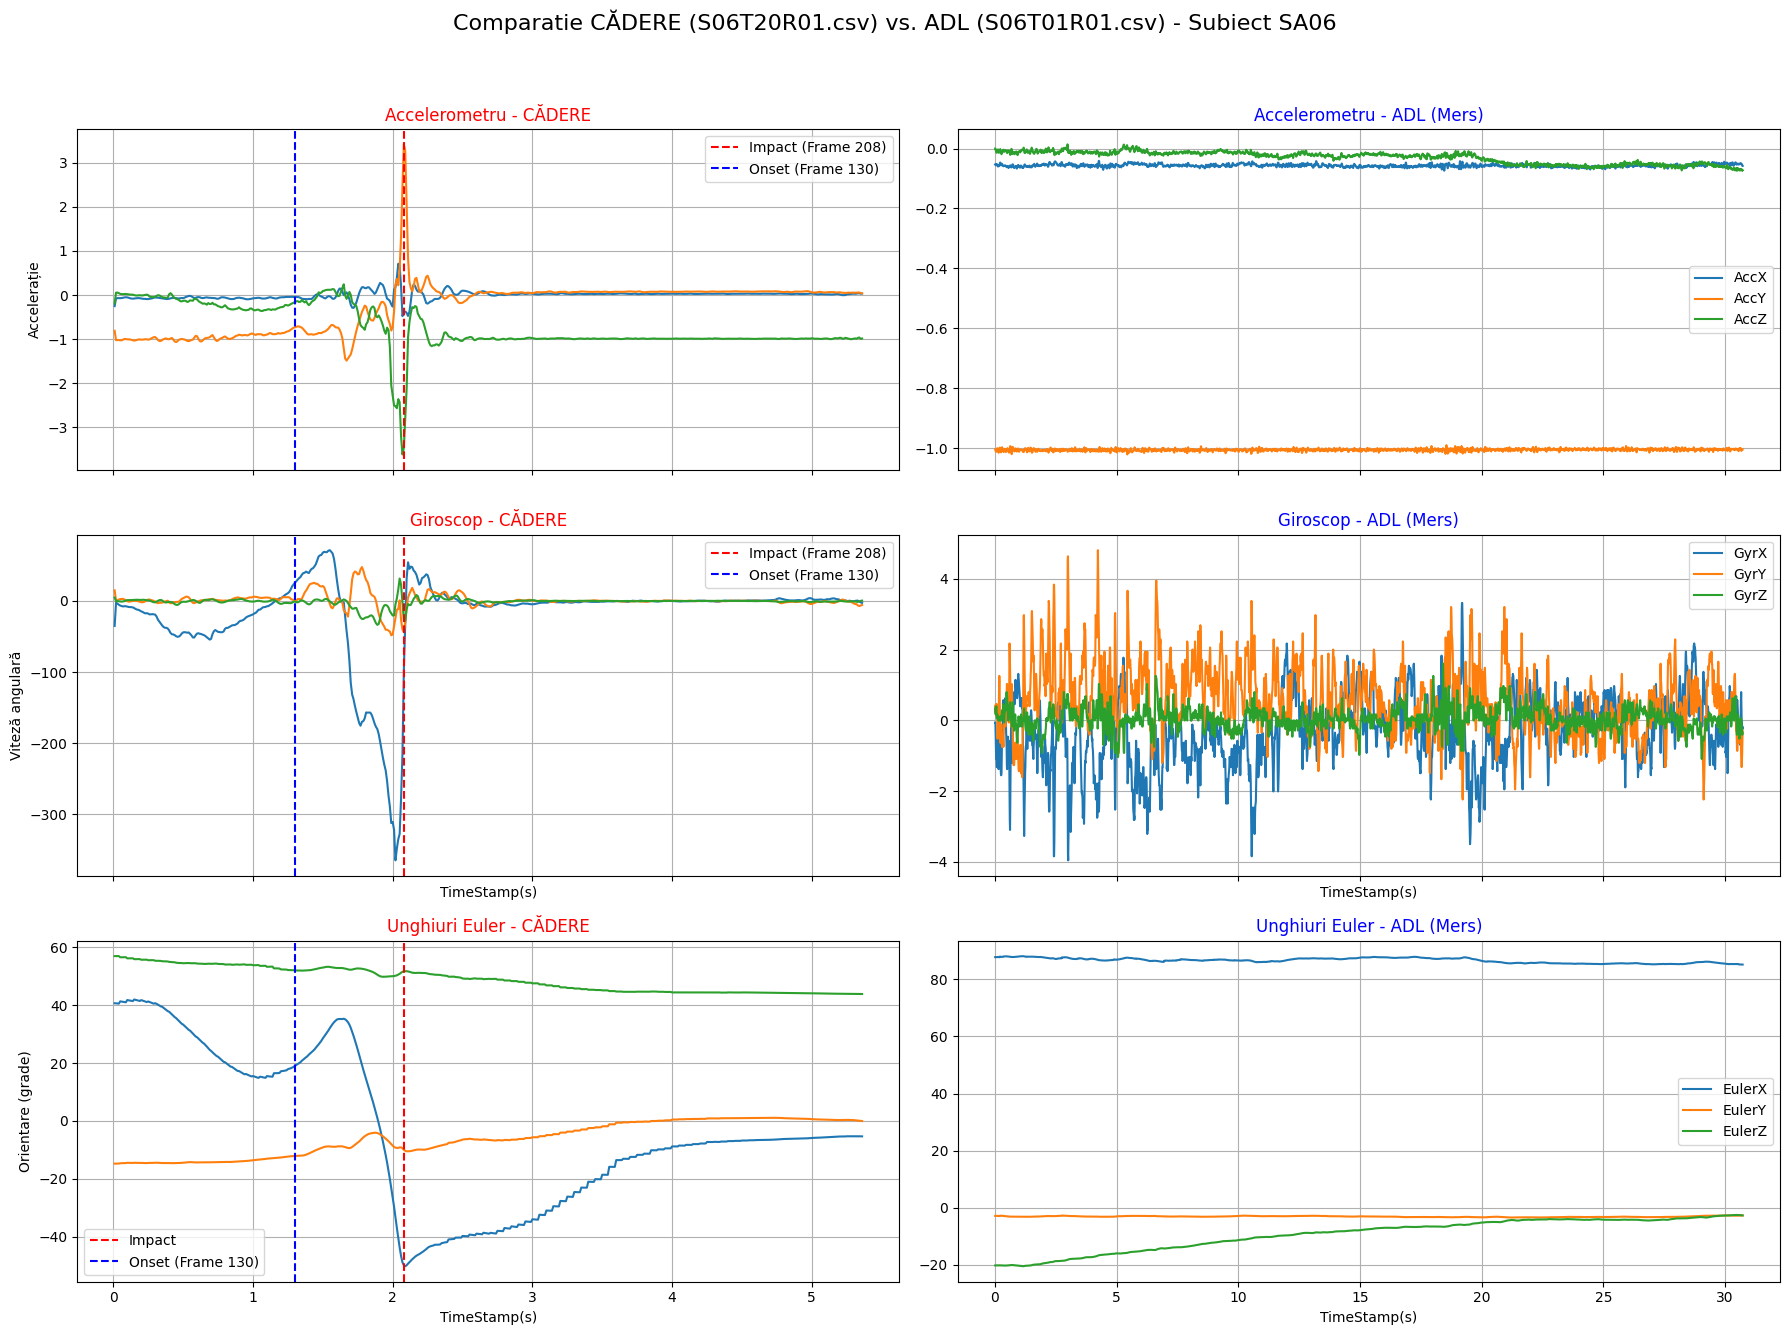

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import re

# --- 1. Definirea Căilor ---
drive_base_path = '/content/drive/MyDrive/Licenta/Datasets/KFall Dataset'
label_data_path = os.path.join(drive_base_path, 'label_data')
sensor_data_path = os.path.join(drive_base_path, 'sensor_data')

subject_id = 'SA06'
subject_id_sensor = 'S06'

# --- 2. Încărcarea fișierului de etichete (labels) ---
try:
    label_file = os.path.join(label_data_path, f'{subject_id}_label.xlsx')
    print(f"Se încarcă fișierul de etichete: {label_file}")
    df_labels = pd.read_excel(label_file)

    # --- 3. Alegerea fișierelor pentru comparație (Logica T-numeric) ---


    fall_info = df_labels.iloc[0]

    # Extragem Task ID-ul numeric (de ex. '20' din 'F01 (20)')
    raw_task_id_string = fall_info['Task Code (Task ID)']
    match = re.search(r'\((\d+)\)', raw_task_id_string)
    if not match:
        raise Exception(f"Nu am putut extrage ID-ul numeric din: {raw_task_id_string}")

    numeric_task_id = int(match.group(1))


    numeric_trial_id = fall_info['Trial ID']

    # Construim numele fișierelor
    fall_task = f"T{numeric_task_id:02d}"  # 20 -> 'T20'
    fall_trial = f"R{numeric_trial_id:02d}" # 1 -> 'R01'

    fall_filename = f'{subject_id_sensor}{fall_task}{fall_trial}.csv'
    fall_file_path = os.path.join(sensor_data_path, subject_id, fall_filename)

    # Alegem un ADL (Mers)
    adl_task = 'T01'
    adl_trial = 'R01'
    adl_filename = f'{subject_id_sensor}{adl_task}{adl_trial}.csv'
    adl_file_path = os.path.join(sensor_data_path, subject_id, adl_filename)

    # Extragem frame-ul de impact
    fall_impact_frame = fall_info['Fall_impact_frame']
    fall_start_frame = fall_info['Fall_onset_frame']

    print(f"\n--- Se compară ---")
    print(f"  [CĂDERE]: {fall_filename} (Impact la frame: {fall_impact_frame})")
    print(f"  [ADL]:    {adl_filename} (Presupus 'Mers')")

    # --- 4. Încărcarea datelor senzorilor ---
    print("Se încarcă fișierele .csv...")
    df_fall = pd.read_csv(fall_file_path)
    df_adl = pd.read_csv(adl_file_path)
    print("Fișierele au fost încărcate cu succes!")

    # --- 5. Vizualizare Comparativă ---
    fig, axes = plt.subplots(3, 2, figsize=(18, 14), sharex='col')
    fig.suptitle(f'Comparatie CĂDERE ({fall_filename}) vs. ADL ({adl_filename}) - Subiect {subject_id}', fontsize=16)

    if 'TimeStamp(s)' not in df_fall.columns or 'FrameCounter' not in df_fall.columns:
         print("Avertisment: Coloanele 'Timestamp' sau 'Frame Number' nu au fost găsite.")
         print("Verifică numele coloanelor din CSV. S-ar putea să fie 'time'?")
         raise Exception("Verifică numele coloanelor în fișierul CSV.")

    x_axis_label = 'TimeStamp(s)'
    x_fall = df_fall['TimeStamp(s)']
    x_adl = df_adl['TimeStamp(s)']

    # Verificăm numele coloanelor de senzori
    acc_cols = ['AccX', 'AccY', 'AccZ']
    if 'AccX' not in df_fall.columns:
        print("Verifică numele coloanelor pentru accelerometru (AccX, AccY, AccZ)")
        raise Exception("Nume coloane accelerometru incorecte.")

    gyro_cols = ['GyrX', 'GyrY', 'GyrZ']
    if 'GyrX' not in df_fall.columns:
        print("Verifică numele coloanelor pentru giroscop (GyrX, GyrY, GyrZ)")
        raise Exception("Nume coloane giroscop incorecte.")

    euler_cols = ['EulerX', 'EulerY', 'EulerZ']
    if 'EulerX' not in df_fall.columns:
        print("Verifică numele coloanelor pentru magnetometru (EulerX, EulerY, EulerZ)")
        raise Exception("Nume coloane magnetometru incorecte.")

    # Găsim timestamp-ul exact al impactului
    impact_row = df_fall.iloc[(df_fall['FrameCounter'] - fall_impact_frame).abs().idxmin()]
    fall_impact_time = impact_row['TimeStamp(s)']
    fall_start_row = df_fall.iloc[(df_fall['FrameCounter'] - fall_start_frame).abs().idxmin()]
    fall_start_time = fall_start_row['TimeStamp(s)']

    # 1. Accelerometru - CĂDERE
    axes[0, 0].plot(x_fall, df_fall[acc_cols])
    axes[0, 0].set_title('Accelerometru - CĂDERE', color='red')
    axes[0, 0].set_ylabel('Accelerație')
    axes[0, 0].grid(True)
    axes[0, 0].axvline(x=fall_impact_time, color='r', linestyle='--', label=f'Impact (Frame {fall_impact_frame})')
    axes[0, 0].axvline(x=fall_start_time, color='b', linestyle='--', label=f'Onset (Frame {fall_start_frame})')
    axes[0, 0].legend()

    # 2. Accelerometru - ADL (Mers)
    axes[0, 1].plot(x_adl, df_adl[acc_cols])
    axes[0, 1].set_title('Accelerometru - ADL (Mers)', color='blue')
    axes[0, 1].legend(acc_cols)
    axes[0, 1].grid(True)

    # 3. Giroscop - CĂDERE
    axes[1, 0].plot(x_fall, df_fall[gyro_cols])
    axes[1, 0].set_title('Giroscop - CĂDERE', color='red')
    axes[1, 0].set_xlabel(x_axis_label)
    axes[1, 0].set_ylabel('Viteză angulară')
    axes[1, 0].grid(True)
    axes[1, 0].axvline(x=fall_impact_time, color='r', linestyle='--', label=f'Impact (Frame {fall_impact_frame})')
    axes[1, 0].axvline(x=fall_start_time, color='b', linestyle='--', label=f'Onset (Frame {fall_start_frame})')
    axes[1, 0].legend()

    # 4. Giroscop - ADL (Mers)
    axes[1, 1].plot(x_adl, df_adl[gyro_cols])
    axes[1, 1].set_title('Giroscop - ADL (Mers)', color='blue')
    axes[1, 1].set_xlabel(x_axis_label)
    axes[1, 1].legend(gyro_cols)
    axes[1, 1].grid(True)

    # 5. Magnetometru - CĂDERE
    axes[2, 0].plot(x_fall, df_fall[euler_cols])
    axes[2, 0].set_title('Unghiuri Euler - CĂDERE', color='red')
    axes[2, 0].set_ylabel('Orientare (grade)')
    axes[2, 0].set_xlabel(x_axis_label)
    axes[2, 0].grid(True)
    axes[2, 0].axvline(x=fall_impact_time, color='r', linestyle='--', label=f'Impact')
    axes[2, 0].axvline(x=fall_start_time, color='b', linestyle='--', label=f'Onset (Frame {fall_start_frame})')
    axes[2, 0].legend()

    # 6. Magnetometru - ADL (Mers)
    axes[2, 1].plot(x_adl, df_adl[euler_cols])
    axes[2, 1].set_title('Unghiuri Euler - ADL (Mers)', color='blue')
    axes[2, 1].set_xlabel(x_axis_label)
    axes[2, 1].legend(euler_cols)
    axes[2, 1].grid(True)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

except FileNotFoundError as e:
    print(f"EROARE: Fișier nu a fost găsit. Verifică calea și numele fișierelor.")
    print(f"Calea exactă căutată: {e.filename}")
except Exception as e:
    print(f"A apărut o eroare neașteptată: {e}")





# Preprocesare date - windowing

In [ ]:
import pandas as pd
import numpy as np
import os
import re

# --- 1. Definirea Parametrilor de Segmentare ---
WINDOW_SIZE_SEC = 1.2
OVERLAP_PERCENT = 0.7

WINDOW_SIZE_SAMPLES = int(SAMPLING_RATE_HZ * WINDOW_SIZE_SEC)
STEP_SIZE_SAMPLES = int(WINDOW_SIZE_SAMPLES * (1 - OVERLAP_PERCENT))

SENSOR_COLUMNS = [
    'AccX', 'AccY', 'AccZ',
    'GyrX', 'GyrY', 'GyrZ',
    #'EulerX', 'EulerY', 'EulerZ'
    'AccMag', 'GyrMag'
]

N_FEATURES = len(SENSOR_COLUMNS)
print(f"Număr de caracteristici per eșantion: {N_FEATURES}")

print(f"--- Configurare Segmentare ---")
print(f"Mărime fereastră: {WINDOW_SIZE_SAMPLES} eșantioane ({WINDOW_SIZE_SEC}s)")
print(f"Pas de alunecare: {STEP_SIZE_SAMPLES} eșantioane ({OVERLAP_PERCENT*100}% suprapunere)")


# --- 2. Funcția de Segmentare ---

def create_windows_smart(dataframe, event_frames, window_size, step_size):
    """
    Segmentează un DataFrame în ferestre cu padding și etichetare inteligentă.

    event_frames: None (pentru ADL) sau un tuplu (onset_frame, impact_frame)
    """
    windows = []
    labels = []

    for i in range(0, len(dataframe), step_size):
        end_index = i + window_size

        # Extragem datele ferestrei
        window_data = dataframe.iloc[i:end_index]

        # Extragem datele senzorilor
        window_sensors = window_data[SENSOR_COLUMNS].values

        current_len = len(window_sensors)
        if current_len < window_size:
            pad_len = window_size - current_len
            # Adăugăm padding la finalul array-ului NumPy
            window_sensors = np.pad(window_sensors, ((0, pad_len), (0, 0)),
                                    'constant', constant_values=0)

        label = 0

        if event_frames is not None:
            _, impact_frame = event_frames

            min_frame = window_data['FrameCounter'].min()
            max_frame = window_data['FrameCounter'].max()



            if min_frame <= impact_frame <= max_frame:
                label = 1

        windows.append(window_sensors)
        labels.append(label)

    return np.array(windows), np.array(labels)


print("\n--- 3. Începe Procesarea Întregului Dataset KFall ---")

# Căile principale
drive_base_path = '/content/drive/MyDrive/Licenta/Datasets/KFall Dataset'
label_data_path = os.path.join(drive_base_path, 'label_data')
sensor_data_path = os.path.join(drive_base_path, 'sensor_data')

# Liste goale pentru a colecta TOATE datele de la TOȚI subiecții
all_subject_windows = []
all_subject_labels = []

# Identificăm toți subiecții din folderul de etichete
try:
    label_files = [f for f in os.listdir(label_data_path) if f.endswith('_label.xlsx')]
    if not label_files:
        print(f"EROARE: Nu am găsit fișiere de etichete în {label_data_path}")
        raise FileNotFoundError("Directorul de etichete este gol sau nu a fost găsit.")

    print(f"Am găsit {len(label_files)} subiecți pentru procesare...")

    # --- BUCLA PRINCIPALĂ (Iterăm prin fiecare subiect) ---
    for label_filename in label_files:

        subject_id = label_filename.split('_')[0] # Ex: 'SA06'
        subject_id_sensor = subject_id.replace('SA', 'S') # Ex: 'S06'

        print(f"\n--- Procesare Subiect: {subject_id} ---")

        # Calea către folderul cu senzori al subiectului
        subject_sensor_dir = os.path.join(sensor_data_path, subject_id)
        if not os.path.isdir(subject_sensor_dir):
            print(f"   [Avertisment] Nu am găsit folderul de senzori: {subject_sensor_dir}. Trecem la următorul.")
            continue

        # Încărcăm fișierul de etichete al subiectului
        label_file_path = os.path.join(label_data_path, label_filename)
        df_labels = pd.read_excel(label_file_path)

        # Set pentru a ține minte ce fișiere sunt 'Căderi'
        fall_files_set = set()

        # --- Sub-Bucla 1: Procesarea fișierelor de CĂDERE ---
        print(f"   Procesare fișiere CĂDERE pentru {subject_id}...")
        for index, fall_info in df_labels.iterrows():
            try:
                # Extragem intervalul evenimentului
                fall_onset_frame = fall_info['Fall_onset_frame']
                fall_impact_frame = fall_info['Fall_impact_frame']

                # Construim numele fișierului (logica din scriptul anterior)
                raw_task_id_string = str(fall_info['Task Code (Task ID)'])
                match = re.search(r'\((\d+)\)', raw_task_id_string)
                if match is None:
                    # print(f"    [Info] Rândul {index} nu conține un Task ID valid, se ignoră.")
                    continue

                numeric_task_id = int(match.group(1))
                numeric_trial_id = fall_info['Trial ID']

                fall_filename = f"{subject_id_sensor}T{numeric_task_id:02d}R{numeric_trial_id:02d}.csv"
                fall_files_set.add(fall_filename)

                fall_file_path = os.path.join(subject_sensor_dir, fall_filename)

                # Încărcăm și segmentăm fișierul de cădere
                df_fall = pd.read_csv(fall_file_path)
                df_fall['AccMag'] = np.sqrt(df_fall['AccX']**2 + df_fall['AccY']**2 + df_fall['AccZ']**2)
                df_fall['GyrMag'] = np.sqrt(df_fall['GyrX']**2 + df_fall['GyrY']**2 + df_fall['GyrZ']**2)
                windows, labels = create_windows_smart(
                    df_fall,
                    (fall_onset_frame, fall_impact_frame),
                    WINDOW_SIZE_SAMPLES,
                    STEP_SIZE_SAMPLES
                )

                all_subject_windows.append(windows)
                all_subject_labels.append(labels)
                # print(f"    [OK] Procesat {fall_filename}: {len(labels)} ferestre ({np.sum(labels)} căderi)")

            except FileNotFoundError:
                print(f"    [EROARE CĂDERE] Fișier lipsă: {fall_filename}")
            except Exception as e:
                print(f"    [EROARE CĂDERE] Eșec la procesarea {fall_filename}: {e}")

        # --- Sub-Bucla 2: Procesarea fișierelor ADL ---
        print(f"   Procesare fișiere ADL pentru {subject_id}...")
        try:
            all_sensor_files = [f for f in os.listdir(subject_sensor_dir) if f.endswith('.csv')]

            for adl_filename in all_sensor_files:
                if adl_filename not in fall_files_set:
                    try:
                        adl_file_path = os.path.join(subject_sensor_dir, adl_filename)

                        # Încărcăm și segmentăm fișierul ADL
                        df_adl = pd.read_csv(adl_file_path)
                        df_adl['AccMag'] = np.sqrt(df_adl['AccX']**2 + df_adl['AccY']**2 + df_adl['AccZ']**2)
                        df_adl['GyrMag'] = np.sqrt(df_adl['GyrX']**2 + df_adl['GyrY']**2 + df_adl['GyrZ']**2)
                        windows, labels = create_windows_smart(
                            df_adl,
                            None, # 'None' înseamnă că nu există impact
                            WINDOW_SIZE_SAMPLES,
                            STEP_SIZE_SAMPLES
                        )

                        all_subject_windows.append(windows)
                        all_subject_labels.append(labels)
                        # print(f"    [OK] Procesat {adl_filename}: {len(labels)} ferestre (toate ADL)")

                    except Exception as e:
                        print(f"    [EROARE ADL] Eșec la procesarea {adl_filename}: {e}")

        except FileNotFoundError:
            print(f"    [EROARE ADL] Directorul de senzori {subject_sensor_dir} nu a fost găsit.")

    # --- 4. Combinarea Finală ---
    print("\n--- 4. Combinarea Tuturor Datelor ---")



    if not all_subject_windows:
        print("EROARE: Nu au fost procesate date. Lista finală este goală.")
    else:
        all_windows = np.concatenate(all_subject_windows, axis=0)
        all_labels = np.concatenate(all_subject_labels, axis=0)

        print("\n--- PROCESARE COMPLETĂ ---")
        print(f"Forma finală a datelor (X): {all_windows.shape}")
        print(f"Forma finală a etichetelor (y): {all_labels.shape}")

        label_counts = np.bincount(all_labels)
        print(f"\nDistribuția totală a etichetelor:")
        print(f"   Ferestre ADL (Eticheta 0):   {label_counts[0]}")
        if len(label_counts) > 1:
            print(f"   Ferestre CĂDERE (Eticheta 1): {label_counts[1]}")
        else:
            print(f"   Ferestre CĂDERE (Eticheta 1): 0")

        print("\nVariabilele 'all_windows' și 'all_labels' sunt gata pentru antrenare.")

except Exception as e:
    print(f"\n--- A APĂRUT O EROARE MAJORĂ ---")
    print(f"Procesarea s-a oprit din cauza: {e}")
    import traceback
    traceback.print_exc()

Număr de caracteristici per eșantion: 8
--- Configurare Segmentare ---
Mărime fereastră: 120 eșantioane (1.2s)
Pas de alunecare: 36 eșantioane (70.0% suprapunere)

--- 3. Începe Procesarea Întregului Dataset KFall ---
Am găsit 32 subiecți pentru procesare...

--- Procesare Subiect: SA29 ---
   Procesare fișiere CĂDERE pentru SA29...
   Procesare fișiere ADL pentru SA29...

--- Procesare Subiect: SA16 ---
   Procesare fișiere CĂDERE pentru SA16...
   Procesare fișiere ADL pentru SA16...

--- Procesare Subiect: SA25 ---
   Procesare fișiere CĂDERE pentru SA25...
   Procesare fișiere ADL pentru SA25...

--- Procesare Subiect: SA09 ---
   Procesare fișiere CĂDERE pentru SA09...
   Procesare fișiere ADL pentru SA09...

--- Procesare Subiect: SA06 ---
   Procesare fișiere CĂDERE pentru SA06...
   Procesare fișiere ADL pentru SA06...

--- Procesare Subiect: SA26 ---
   Procesare fișiere CĂDERE pentru SA26...
   Procesare fișiere ADL pentru SA26...

--- Procesare Subiect: SA33 ---
   Procesare

# Antrenarea modelului

--- 1. Pregătirea Datelor pentru SVM ---
Forma datelor 3D originale (X): (42465, 200, 9)
Forma datelor 2D aplatizate (X): (42465, 1800)
Forma etichetelor (y): (42465,)

--- 2. Împărțirea Setului de Date ---
Total eșantioane: 42465
Eșantioane de antrenament (X_train): 33972
Eșantioane de test (X_test): 8493
Distribuție 'Căderi' în antrenament: 1050 / 33972
Distribuție 'Căderi' în test: 262 / 8493

--- 3. Scalarea Datelor ---
Datele de antrenament și test au fost scalate.

--- 4. Antrenarea Modelului SVM ---
Acest pas poate dura câteva momente...
Model SVM antrenat cu succes.

--- 5. REZULTATE ȘI METRICI (pe setul de TEST) ---
Acuratețea Generală (Accuracy): 93.45%

--- Raport de Clasificare Detaliat ---
                  precision    recall  f1-score   support

   ADL (Clasa 0)       0.98      0.95      0.97      8231
Cădere (Clasa 1)       0.18      0.32      0.23       262

        accuracy                           0.93      8493
       macro avg       0.58      0.64      0.60      8

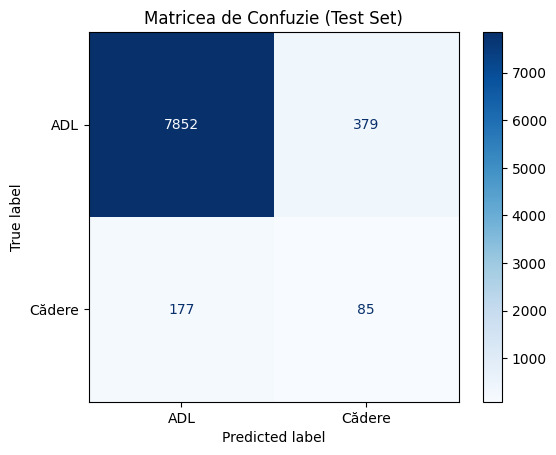


Interpretarea Matricei de Confuzie:
  Adevărat Negativ (TN): 7852 (ADL-uri corect identificate)
  Fals Pozitiv (FP):   379 (ADL-uri clasificate greșit ca 'Cădere')
  Fals Negativ (FN):   177 (Căderi ratate, clasificate greșit ca 'ADL')
  Adevărat Pozitiv (TP): 85 (Căderi corect identificate)


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# --- 1. Pregătirea Datelor pentru SVM ---

print("--- 1. Pregătirea Datelor pentru SVM ---")


if 'all_windows' not in locals() or 'all_labels' not in locals():
    print("EROARE: Datele 'all_windows' și 'all_labels' nu au fost găsite.")
    print("Vă rugăm să rulați mai întâi scriptul de segmentare.")
else:
    n_samples = all_windows.shape[0]
    X_flattened = all_windows.reshape(n_samples, -1)
    y = all_labels

    print(f"Forma datelor 3D originale (X): {all_windows.shape}")
    print(f"Forma datelor 2D aplatizate (X): {X_flattened.shape}")
    print(f"Forma etichetelor (y): {y.shape}")

    # --- 2. Împărțirea Setului de Date (80% Train, 20% Test) ---

    print("\n--- 2. Împărțirea Setului de Date ---")


    X_train, X_test, y_train, y_test = train_test_split(
        X_flattened,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    print(f"Total eșantioane: {len(y)}")
    print(f"Eșantioane de antrenament (X_train): {X_train.shape[0]}")
    print(f"Eșantioane de test (X_test): {X_test.shape[0]}")
    print(f"Distribuție 'Căderi' în antrenament: {np.sum(y_train)} / {len(y_train)}")
    print(f"Distribuție 'Căderi' în test: {np.sum(y_test)} / {len(y_test)}")


    # --- 3. Scalarea Datelor ---

    print("\n--- 3. Scalarea Datelor ---")


    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(X_train)

    X_test_scaled = scaler.transform(X_test)

    print("Datele de antrenament și test au fost scalate.")

    # --- 4. Antrenarea Modelului SVM ---

    print("\n--- 4. Antrenarea Modelului SVM ---")
    print("Acest pas poate dura câteva momente...")

    model = SVC(kernel='rbf', class_weight='balanced', random_state=42)

    # Antrenăm modelul
    model.fit(X_train_scaled, y_train)

    print("Model SVM antrenat cu succes.")

    # --- 5. Evaluarea și Metricile Eficienței ---

    print("\n--- 5. REZULTATE ȘI METRICI (pe setul de TEST) ---")

    y_pred = model.predict(X_test_scaled)

    # Acuratețea Generală
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Acuratețea Generală (Accuracy): {accuracy * 100:.2f}%")

    print("\n--- Raport de Clasificare Detaliat ---")
    # Precision, Recall, F1-Score
    print(classification_report(y_test, y_pred, target_names=['ADL (Clasa 0)', 'Cădere (Clasa 1)']))

    print("\n--- Matrice de Confuzie ---")
    # Afișează o defalcare a predicțiilor corecte/greșite
    cm = confusion_matrix(y_test, y_pred)

    # Folosim ConfusionMatrixDisplay pentru o vizualizare mai clară
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=['ADL', 'Cădere'])

    disp.plot(cmap=plt.cm.Blues)
    plt.title("Matricea de Confuzie (Test Set)")
    plt.show()

    print("\nInterpretarea Matricei de Confuzie:")
    print(f"  Adevărat Negativ (TN): {cm[0][0]} (ADL-uri corect identificate)")
    print(f"  Fals Pozitiv (FP):   {cm[0][1]} (ADL-uri clasificate greșit ca 'Cădere')")
    print(f"  Fals Negativ (FN):   {cm[1][0]} (Căderi ratate, clasificate greșit ca 'ADL')")
    print(f"  Adevărat Pozitiv (TP): {cm[1][1]} (Căderi corect identificate)")

--- 1. Pregătirea Datelor ---

--- 2. Împărțirea Setului de Date ---
Forma X_train (înainte de Under-sampling): (90730, 120, 8)
Forma X_test (original): (22683, 120, 8)
Distribuție y_train (înainte): [89456  1274]

--- 3. Scalarea Datelor (StandardScaler) ---
Datele de antrenament și test au fost scalate.

--- 4. Aplicarea Random Under-sampling ---
Forma X_train (după Under-sampling): (2548, 120, 8)
Distribuție y_train (după): [1274 1274]

--- 5. Construirea Modelului Hibrid CNN-LSTM (SIMPLU) ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_17 (Conv1D)              │ (None, 120, 64)        │         2,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_17 (MaxPooling1D) │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,713 (139.50 KB)

 Trainable params: 35,713 (139.50 KB)

 Non-trainable params: 0 (0.00 B)


--- 6. Antrenarea Modelului (pe datele echilibrate) ---
Dimensiune antrenament final: (2038, 120, 8)
Dimensiune validare finală: (510, 120, 8)
Epoch 1/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.7500 - loss: 0.5242 - val_accuracy: 0.9255 - val_loss: 0.2347
Epoch 2/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9176 - loss: 0.2379 - val_accuracy: 0.9529 - val_loss: 0.1856
Epoch 3/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9512 - loss: 0.1798 - val_accuracy: 0.9608 - val_loss: 0.1374
Epoch 4/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9495 - loss: 0.1715 - val_accuracy: 0.9647 - val_loss: 0.1305
Epoch 5/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9627 - loss: 0.1340 - val_accuracy: 0.9588 - val_loss: 0.1435
Epoch 6/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9623 - loss: 0.1371 - val_accuracy: 0.9608 - val_loss: 0.1380
Epoch 7/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9696 - loss: 0.1183 - val_accurac

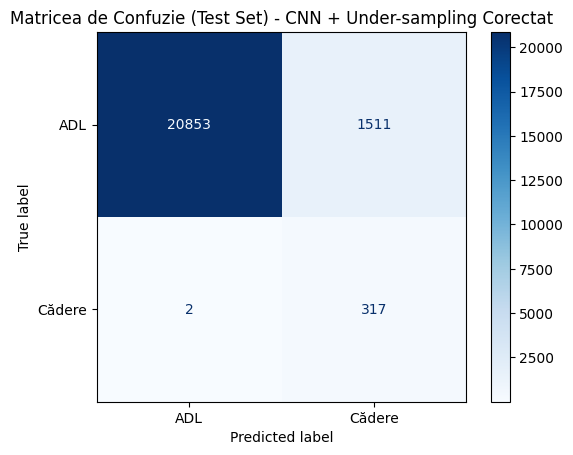

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout, Flatten
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils import class_weight
from tensorflow.keras.callbacks import EarlyStopping
from imblearn.under_sampling import RandomUnderSampler


early_stopping_callback = EarlyStopping(
    monitor='val_loss',
    patience=7,
    verbose=1,
    restore_best_weights=True
)

# --- 1. Pregătirea Datelor ---
print("--- 1. Pregătirea Datelor ---")
X = all_windows
y = all_labels

# --- 2. Împărțirea Setului de Date (80% Train, 20% Test) ---
print("\n--- 2. Împărțirea Setului de Date ---")
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Forma X_train (înainte de Under-sampling): {X_train.shape}")
print(f"Forma X_test (original): {X_test.shape}")
print(f"Distribuție y_train (înainte): {np.bincount(y_train)}")

# --- 3. Scalarea Datelor (Pas Critic!) ---
print("\n--- 3. Scalarea Datelor (StandardScaler) ---")
n_samples_train, n_timesteps, n_features = X_train.shape
X_train_reshaped = X_train.reshape(-1, n_features)

scaler = StandardScaler()
scaler.fit(X_train_reshaped)

X_train_scaled = scaler.transform(X_train_reshaped).reshape(n_samples_train, n_timesteps, n_features)

n_samples_test = X_test.shape[0]
X_test_reshaped = X_test.reshape(-1, n_features)
X_test_scaled = scaler.transform(X_test_reshaped).reshape(n_samples_test, n_timesteps, n_features)
print("Datele de antrenament și test au fost scalate.")

# --- 4.Aplicarea Random Under-sampling ---
print("\n--- 4. Aplicarea Random Under-sampling ---")
X_train_flat_for_sampling = X_train_scaled.reshape(n_samples_train, -1)


rus = RandomUnderSampler(sampling_strategy=1.0, # 1.0 înseamnă raport 1:1
                         random_state=42)

X_train_us_flat, y_train_us = rus.fit_resample(X_train_flat_for_sampling, y_train)

X_train_us_3d = X_train_us_flat.reshape(-1, n_timesteps, n_features)

print(f"Forma X_train (după Under-sampling): {X_train_us_3d.shape}")
print(f"Distribuție y_train (după): {np.bincount(y_train_us)}")

# --- 5. Construirea Modelului HIBRID (SIMPLIFICAT) ---
print("\n--- 5. Construirea Modelului Hibrid CNN-LSTM (SIMPLU) ---")

from tensorflow.keras.layers import LSTM, TimeDistributed, GlobalMaxPooling1D

INPUT_SHAPE = (X_train_us_3d.shape[1], X_train_us_3d.shape[2]) # (120, 8)

model = Sequential([
    Conv1D(filters=64, kernel_size=5, activation='relu', input_shape=INPUT_SHAPE, padding='same'),
    MaxPooling1D(pool_size=2),
    Dropout(0.4),

    LSTM(units=64),
    Dropout(0.4),

    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

# --- 6. Antrenarea Modelului (CU VALIDARE CORECTĂ) ---
print("\n--- 6. Antrenarea Modelului (pe datele echilibrate) ---")

X_train_final, X_val_final, y_train_final, y_val_final = train_test_split(
    X_train_us_3d,
    y_train_us,
    test_size=0.2,
    random_state=42,
    stratify=y_train_us
)

print(f"Dimensiune antrenament final: {X_train_final.shape}")
print(f"Dimensiune validare finală: {X_val_final.shape}")

early_stopping_callback = EarlyStopping(
    monitor='val_loss',
    patience=10,
    verbose=1,
    restore_best_weights=True
)

history = model.fit(
    X_train_final,
    y_train_final,
    epochs=50,
    batch_size=32,
    validation_data=(X_val_final, y_val_final),
    callbacks=[early_stopping_callback],
    verbose=1
)

print("Antrenament finalizat.")

# --- 7. Evaluarea Modelului (pe datele de TEST ORIGINALE) ---
print("\n--- 7. REZULTATE ȘI METRICI (pe setul de TEST original) ---")
print("Acum evaluăm pe setul de test original, dezechilibrat...")

loss, accuracy = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Acuratețea Generală (Accuracy) pe Test: {accuracy * 100:.2f}%")

y_pred_proba = model.predict(X_test_scaled)
y_pred = (y_pred_proba > 0.5).astype(int).flatten()

print("\n--- Raport de Clasificare Detaliat ---")
print(classification_report(y_test, y_pred, target_names=['ADL (Clasa 0)', 'Cădere (Clasa 1)']))

print("\n--- Matrice de Confuzie ---")
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['ADL', 'Cădere'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Matricea de Confuzie (Test Set) - CNN + Under-sampling Corectat")
plt.show()


--- 7. REZULTATE ȘI METRICI (pe setul de TEST) ---
Acuratețea Generală (Accuracy) pe Test: 93.74%
709/709 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step

--- Raport de Clasificare Detaliat ---
                  precision    recall  f1-score   support

   ADL (Clasa 0)       1.00      0.95      0.97     22364
Cădere (Clasa 1)       0.19      0.89      0.32       319

        accuracy                           0.95     22683
       macro avg       0.60      0.92      0.64     22683
    weighted avg       0.99      0.95      0.96     22683


--- Matrice de Confuzie ---


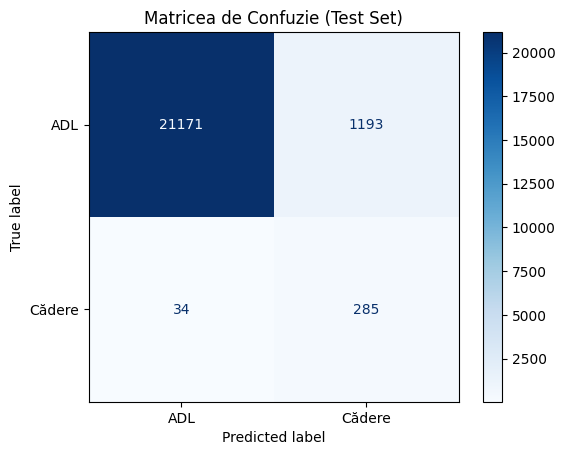


--- 8. Istoricul Antrenamentului ---


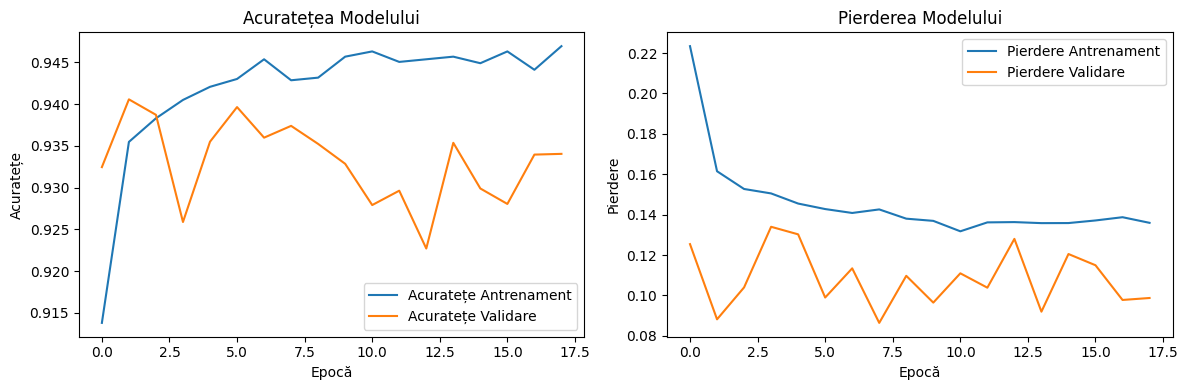

In [ ]:
# --- 7. Evaluarea Modelului ---
print("\n--- 7. REZULTATE ȘI METRICI (pe setul de TEST) ---")


loss, accuracy = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Acuratețea Generală (Accuracy) pe Test: {accuracy * 100:.2f}%")

y_pred_proba = model.predict(X_test_scaled)
y_pred = (y_pred_proba > 0.6).astype(int).flatten()

print("\n--- Raport de Clasificare Detaliat ---")
print(classification_report(y_test, y_pred, target_names=['ADL (Clasa 0)', 'Cădere (Clasa 1)']))

print("\n--- Matrice de Confuzie ---")
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['ADL', 'Cădere'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Matricea de Confuzie (Test Set)")
plt.show()

# --- 8. Vizualizarea Antrenamentului ---
print("\n--- 8. Istoricul Antrenamentului ---")

plt.figure(figsize=(12, 4))
# Graficul acurateței
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Acuratețe Antrenament')
plt.plot(history.history['val_accuracy'], label='Acuratețe Validare')
plt.title('Acuratețea Modelului')
plt.xlabel('Epocă')
plt.ylabel('Acuratețe')
plt.legend()
# Graficul pierderii
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Pierdere Antrenament')
plt.plot(history.history['val_loss'], label='Pierdere Validare')
plt.title('Pierderea Modelului')
plt.xlabel('Epocă')
plt.ylabel('Pierdere')
plt.legend()
plt.tight_layout()
plt.show()

Preprocesre date 2

In [ ]:
import pandas as pd
import numpy as np
import os
import re
from scipy.stats import skew, kurtosis
from scipy.signal import find_peaks

# --- 1. Parametrii (la fel ca înainte) ---
SAMPLING_RATE_HZ = 100
WINDOW_SIZE_SEC = 1.2
OVERLAP_PERCENT = 0.7

WINDOW_SIZE_SAMPLES = int(SAMPLING_RATE_HZ * WINDOW_SIZE_SEC)
STEP_SIZE_SAMPLES = int(WINDOW_SIZE_SAMPLES * (1 - OVERLAP_PERCENT))

BASE_SENSOR_COLUMNS = [
    'AccX', 'AccY', 'AccZ',
    'GyrX', 'GyrY', 'GyrZ',
    'AccMag', 'GyrMag'
]

print(f"--- Configurare Extracție Caracteristici ---")
print(f"Mărime fereastră: {WINDOW_SIZE_SAMPLES} eșantioane")
print(f"Pas de alunecare: {STEP_SIZE_SAMPLES} eșantioane")

# --- 2. Funcție de Extracție Caracteristici ---

def extract_statistical_features(window_data_segment):
    """
    Calculează un set de caracteristici statistice pentru un segment de fereastră.
    'window_data_segment' este un array NumPy de (200, 8).
    """
    features = []
    for i in range(window_data_segment.shape[1]):
        col_data = window_data_segment[:, i]

        features.append(np.mean(col_data))
        features.append(np.std(col_data))
        features.append(np.min(col_data))
        features.append(np.max(col_data))
        features.append(np.max(col_data) - np.min(col_data))
        features.append(np.median(col_data))
        features.append(np.sum(np.square(col_data)))
        features.append(skew(col_data))
        features.append(kurtosis(col_data))

    return np.array(features)

# --- 3. Funcția de Segmentare și Extracție (MODIFICATĂ) ---

def create_feature_windows(dataframe, impact_frame, window_size, step_size):
    """
    Segmentează, aplică padding și extrage caracteristici.
    """
    feature_list = []
    labels = []

    for i in range(0, len(dataframe), step_size):
        end_index = i + window_size
        window_data = dataframe.iloc[i:end_index]

        window_sensors = window_data[BASE_SENSOR_COLUMNS].values

        current_len = len(window_sensors)
        if current_len < window_size:
            pad_len = window_size - current_len
            window_sensors = np.pad(window_sensors, ((0, pad_len), (0, 0)),
                                    'constant', constant_values=0)

        # --- Extracția Caracteristicilor ---
        extracted_features = extract_statistical_features(window_sensors)

        label = 0
        if impact_frame is not None:
            min_frame = window_data['FrameCounter'].min()
            max_frame = window_data['FrameCounter'].max()
            if min_frame <= impact_frame <= max_frame:
                label = 1

        feature_list.append(extracted_features)
        labels.append(label)

    return np.array(feature_list), np.array(labels)

# --- 4. Execuția Procesului ---

print("\n--- 3. Începe Procesarea Întregului Dataset (Extracție Caracteristici) ---")
drive_base_path = '/content/drive/MyDrive/Licenta/Datasets/KFall Dataset'
label_data_path = os.path.join(drive_base_path, 'label_data')
sensor_data_path = os.path.join(drive_base_path, 'sensor_data')

all_subject_features = []
all_subject_labels = []

try:
    label_files = [f for f in os.listdir(label_data_path) if f.endswith('_label.xlsx')]
    print(f"Am găsit {len(label_files)} subiecți pentru procesare...")

    for label_filename in label_files:
        subject_id = label_filename.split('_')[0]
        subject_id_sensor = subject_id.replace('SA', 'S')
        print(f"\n--- Procesare Subiect: {subject_id} ---")

        subject_sensor_dir = os.path.join(sensor_data_path, subject_id)
        if not os.path.isdir(subject_sensor_dir):
            continue

        label_file_path = os.path.join(label_data_path, label_filename)
        df_labels = pd.read_excel(label_file_path)
        fall_files_set = set()

        # --- Sub-Bucla 1: CĂDERI ---
        for index, fall_info in df_labels.iterrows():
            try:
                fall_impact_frame = fall_info['Fall_impact_frame']
                raw_task_id_string = str(fall_info['Task Code (Task ID)'])
                match = re.search(r'\((\d+)\)', raw_task_id_string)
                if match is None: continue

                numeric_task_id = int(match.group(1))
                numeric_trial_id = fall_info['Trial ID']
                fall_filename = f"{subject_id_sensor}T{numeric_task_id:02d}R{numeric_trial_id:02d}.csv"
                fall_files_set.add(fall_filename)
                fall_file_path = os.path.join(subject_sensor_dir, fall_filename)

                df_fall = pd.read_csv(fall_file_path)
                # Calculăm caracteristicile noi
                df_fall['AccMag'] = np.sqrt(df_fall['AccX']**2 + df_fall['AccY']**2 + df_fall['AccZ']**2)
                df_fall['GyrMag'] = np.sqrt(df_fall['GyrX']**2 + df_fall['GyrY']**2 + df_fall['GyrZ']**2)

                features, labels = create_feature_windows(
                    df_fall,
                    fall_impact_frame,
                    WINDOW_SIZE_SAMPLES,
                    STEP_SIZE_SAMPLES
                )
                all_subject_features.append(features)
                all_subject_labels.append(labels)
            except Exception as e:
                print(f"    [EROARE CĂDERE] {fall_filename}: {e}")

        # --- Sub-Bucla 2: ADL ---
        all_sensor_files = [f for f in os.listdir(subject_sensor_dir) if f.endswith('.csv')]
        for adl_filename in all_sensor_files:
            if adl_filename not in fall_files_set:
                try:
                    adl_file_path = os.path.join(subject_sensor_dir, adl_filename)
                    df_adl = pd.read_csv(adl_file_path)

                    # Calculăm caracteristicile noi
                    df_adl['AccMag'] = np.sqrt(df_adl['AccX']**2 + df_adl['AccY']**2 + df_adl['AccZ']**2)
                    df_adl['GyrMag'] = np.sqrt(df_adl['GyrX']**2 + df_adl['GyrY']**2 + df_adl['GyrZ']**2)

                    features, labels = create_feature_windows(
                        df_adl,
                        None,
                        WINDOW_SIZE_SAMPLES,
                        STEP_SIZE_SAMPLES
                    )
                    all_subject_features.append(features)
                    all_subject_labels.append(labels)
                except Exception as e:
                    print(f"    [EROARE ADL] {adl_filename}: {e}")

    # --- 5. Combinarea Finală ---
    print("\n--- 5. Combinarea Tuturor Caracteristicilor ---")

    X_features = np.concatenate(all_subject_features, axis=0)
    y_labels = np.concatenate(all_subject_labels, axis=0)

    print("\n--- PROCESARE COMPLETĂ (CARACTERISTICI) ---")
    print(f"Forma finală a datelor (X): {X_features.shape}")
    print(f"Forma finală a etichetelor (y): {y_labels.shape}")
    print(f"Distribuția etichetelor: {np.bincount(y_labels)}")
    print("\nVariabilele 'X_features' și 'y_labels' sunt gata.")

except Exception as e:
    print(f"A apărut o eroare majoră: {e}")

--- Configurare Extracție Caracteristici ---
Mărime fereastră: 120 eșantioane
Pas de alunecare: 36 eșantioane

--- 3. Începe Procesarea Întregului Dataset (Extracție Caracteristici) ---
Am găsit 32 subiecți pentru procesare...

--- Procesare Subiect: SA29 ---

--- Procesare Subiect: SA16 ---

--- Procesare Subiect: SA25 ---

--- Procesare Subiect: SA09 ---

--- Procesare Subiect: SA06 ---

--- Procesare Subiect: SA26 ---

--- Procesare Subiect: SA33 ---

--- Procesare Subiect: SA31 ---

--- Procesare Subiect: SA28 ---

--- Procesare Subiect: SA19 ---

--- Procesare Subiect: SA10 ---

--- Procesare Subiect: SA32 ---

--- Procesare Subiect: SA13 ---

--- Procesare Subiect: SA20 ---

--- Procesare Subiect: SA30 ---

--- Procesare Subiect: SA07 ---

--- Procesare Subiect: SA11 ---

--- Procesare Subiect: SA08 ---

--- Procesare Subiect: SA14 ---

--- Procesare Subiect: SA17 ---

--- Procesare Subiect: SA24 ---

--- Procesare Subiect: SA22 ---

--- Procesare Subiect: SA35 ---

--- Procesare

Random Forest

--- 1. Pregătirea Datelor pentru Random Forest ---

--- 2. Împărțirea Setului de Date ---
Dimensiune X_train (înainte): (90730, 72)
Distribuție y_train (înainte): [89456  1274]

--- 3. Curățarea datelor (Imputarea NaN-urilor) ---
Valorile NaN au fost înlocuite cu 0.

--- 4. Aplicarea Random Under-sampling (Raport 1:1) ---
Dimensiune X_train (după Under-sampling): (2548, 72)
Distribuție y_train (după): [1274 1274]

--- 5. Antrenarea Modelului Random Forest (pe datele 1:1) ---
Model antrenat.

--- 6. REZULTATE ȘI METRICI (pe setul de TEST original) ---
Acuratețea Generală (Accuracy) pe Test: 93.56%

--- Raport de Clasificare Detaliat ---
                  precision    recall  f1-score   support

   ADL (Clasa 0)       1.00      0.93      0.97     22364
Cădere (Clasa 1)       0.18      0.99      0.30       319

        accuracy                           0.94     22683
       macro avg       0.59      0.96      0.63     22683
    weighted avg       0.99      0.94      0.96     22683


--- 

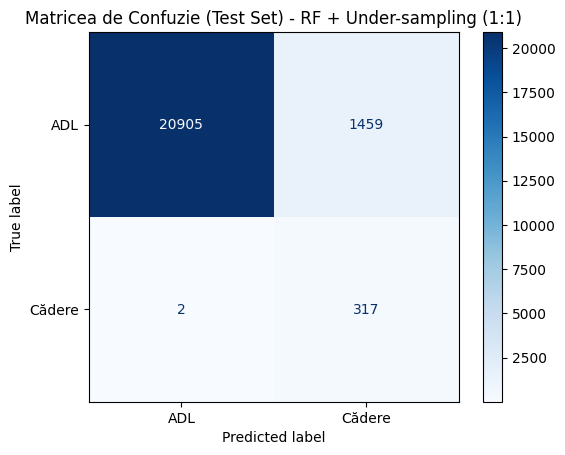


--- 7. Importanța Caracteristicilor ---


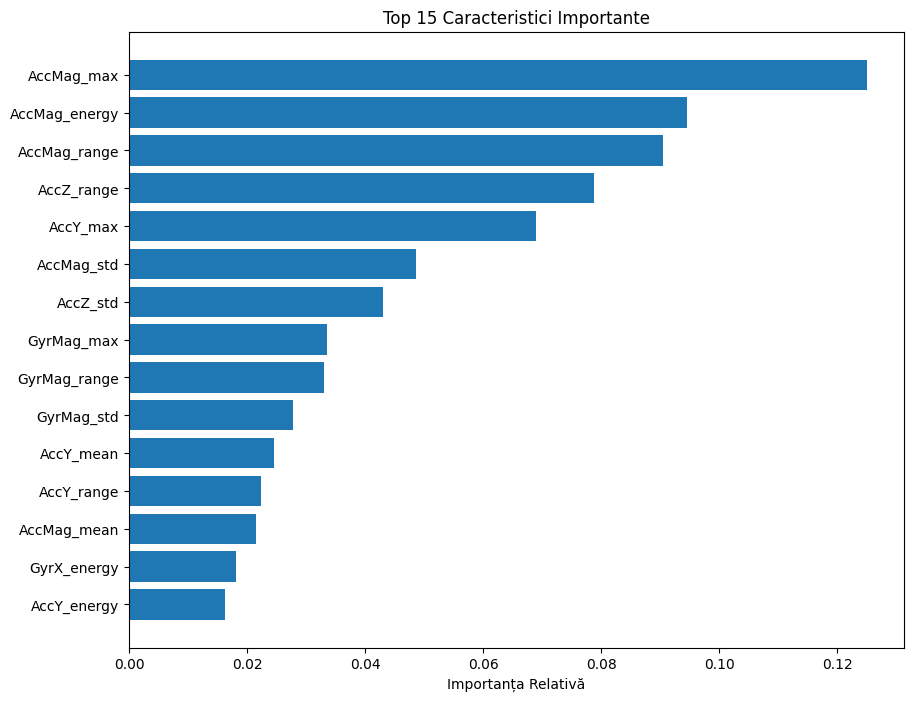

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from imblearn.under_sampling import RandomUnderSampler # <-- Folosim Under-sampling
from sklearn.impute import SimpleImputer # <-- Încă avem nevoie de Imputer

# --- 1. Pregătirea Datelor ---
print("--- 1. Pregătirea Datelor pentru Random Forest ---")
# Presupunem că 'X_features' și 'y_labels' există (din 1.2s)
X = X_features
y = y_labels

# --- 2. Împărțirea Setului de Date (80% Train, 20% Test) ---
print("\n--- 2. Împărțirea Setului de Date ---")
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Dimensiune X_train (înainte): {X_train.shape}")
print(f"Distribuție y_train (înainte): {np.bincount(y_train)}")

# --- 3. Curățarea datelor (Imputarea NaN-urilor) ---
print("\n--- 3. Curățarea datelor (Imputarea NaN-urilor) ---")
imputer = SimpleImputer(strategy='constant', fill_value=0)
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)
print("Valorile NaN au fost înlocuite cu 0.")

# --- 4. Aplicarea Random Under-sampling (Raport 1:1) ---
print("\n--- 4. Aplicarea Random Under-sampling (Raport 1:1) ---")

rus = RandomUnderSampler(sampling_strategy=1.0, # 1.0 = raport 1:1
                         random_state=42)
X_train_resampled, y_train_resampled = rus.fit_resample(X_train, y_train)

print(f"Dimensiune X_train (după Under-sampling): {X_train_resampled.shape}")
print(f"Distribuție y_train (după): {np.bincount(y_train_resampled)}")

# --- 5. Antrenarea Modelului Random Forest ---
print("\n--- 5. Antrenarea Modelului Random Forest (pe datele 1:1) ---")

# FĂRĂ 'class_weight', deoarece datele sunt acum perfect echilibrate
model = RandomForestClassifier(
    n_estimators=150,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train_resampled, y_train_resampled)
print("Model antrenat.")

# --- 6. Evaluarea Modelului (pe datele de TEST ORIGINALE) ---
print("\n--- 6. REZULTATE ȘI METRICI (pe setul de TEST original) ---")

y_pred = model.predict(X_test)

print(f"Acuratețea Generală (Accuracy) pe Test: {accuracy_score(y_test, y_pred) * 100:.2f}%")

print("\n--- Raport de Clasificare Detaliat ---")
print(classification_report(y_test, y_pred, target_names=['ADL (Clasa 0)', 'Cădere (Clasa 1)']))

print("\n--- Matrice de Confuzie ---")
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['ADL', 'Cădere'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Matricea de Confuzie (Test Set) - RF + Under-sampling (1:1)")
plt.show()

# --- 7. Importanța Caracteristicilor (Opțional) ---
try:
    print("\n--- 7. Importanța Caracteristicilor ---")

    feature_names = []
    stats = ['mean', 'std', 'min', 'max', 'range', 'median', 'energy', 'skew', 'kurt']
    if 'BASE_SENSOR_COLUMNS' not in locals():
         BASE_SENSOR_COLUMNS = ['AccX', 'AccY', 'AccZ', 'GyrX', 'GyrY', 'GyrZ', 'AccMag', 'GyrMag']

    for sensor in BASE_SENSOR_COLUMNS:
        for stat in stats:
            feature_names.append(f"{sensor}_{stat}")

    importances = model.feature_importances_
    indices = np.argsort(importances)[-15:] # Luăm top 15

    plt.figure(figsize=(10, 8))
    plt.title('Top 15 Caracteristici Importante')
    plt.barh(range(len(indices)), importances[indices], align='center')
    plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
    plt.xlabel('Importanța Relativă')
    plt.show()
except Exception as e:
    print(f"Nu am putut afișa importanța caracteristicilor: {e}")

# Folosirea impactului si momentul de dupa impact


In [ ]:
import pandas as pd
import numpy as np
import os
import re
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout, BatchNormalization
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.utils import class_weight
from tensorflow.keras.callbacks import EarlyStopping

# --- 1. Parametrii de Segmentare (Din Articol) ---
SAMPLING_RATE_HZ = 100
WINDOW_SIZE_SEC = 0.5  # <-- MODIFICARE CRITICĂ: 0.5s (50 eșantioane)
OVERLAP_PERCENT = 0.5  # Suprapunere standard de 50%

WINDOW_SIZE_SAMPLES = int(SAMPLING_RATE_HZ * WINDOW_SIZE_SEC) # 50 eșantioane
STEP_SIZE_SAMPLES = int(WINDOW_SIZE_SAMPLES * (1 - OVERLAP_PERCENT)) # 25 eșantioane

# Vom folosi 8 caracteristici (Acc, Gyr + Magnitudinile)
SENSOR_COLUMNS = [
    'AccX', 'AccY', 'AccZ',
    'GyrX', 'GyrY', 'GyrZ',
    'EulerX', 'EulerY', 'EulerZ'
]
N_FEATURES = len(SENSOR_COLUMNS)

print(f"--- Configurare Segmentare (Articol) ---")
print(f"Mărime fereastră: {WINDOW_SIZE_SAMPLES} eșantioane ({WINDOW_SIZE_SEC}s)")
print(f"Pas de alunecare: {STEP_SIZE_SAMPLES} eșantioane")

# --- 2. Funcția de Segmentare (Pre-Impact) ---

def create_windows_pre_impact(dataframe, event_interval, window_size, step_size):
    """
    Segmentează un DataFrame și etichetează ferestrele care se suprapun
    cu intervalul de pre-impact [onset, impact].
    """
    windows = []
    labels = []

    for i in range(0, len(dataframe), step_size):
        end_index = i + window_size
        window_data = dataframe.iloc[i:end_index]
        window_sensors = window_data[SENSOR_COLUMNS].values

        # --- Padding (dacă e ultima fereastră și e incompletă) ---
        current_len = len(window_sensors)
        if current_len < window_size:
            pad_len = window_size - current_len
            window_sensors = np.pad(window_sensors, ((0, pad_len), (0, 0)),
                                    'constant', constant_values=0)

        # --- Logică de Etichetare (Pre-Impact) ---
        label = 0 # Presupunem 0 (ADL)

        if event_interval is not None:
            onset_frame, impact_frame = event_interval

            # Găsim frame-urile reale acoperite de această fereastră
            min_frame = window_data['FrameCounter'].min()
            max_frame = window_data['FrameCounter'].max()

            # Condiția de suprapunere: (A <= D) and (B >= C)
            if (min_frame <= impact_frame) and (max_frame >= onset_frame):
                label = 1 # Este o fereastră de CĂDERE (Pre-Impact)

        windows.append(window_sensors)
        labels.append(label)

    return np.array(windows), np.array(labels)

# --- 3. Execuția Procesului (Colectare pe Subiect) ---

print("\n--- 3. Începe Procesarea (Colectare pe Subiect) ---")
drive_base_path = '/content/drive/MyDrive/Licenta/Datasets/KFall Dataset'
label_data_path = os.path.join(drive_base_path, 'label_data')
sensor_data_path = os.path.join(drive_base_path, 'sensor_data')

# Dictionar pentru a stoca datele separat pentru fiecare subiect
all_data_by_subject = {}

try:
    label_files = [f for f in os.listdir(label_data_path) if f.endswith('_label.xlsx')]
    print(f"Am găsit {len(label_files)} subiecți pentru procesare...")

    for label_filename in label_files:
        subject_id = label_filename.split('_')[0] # Ex: 'SA06'
        subject_id_sensor = subject_id.replace('SA', 'S')
        # print(f"Procesare Subiect: {subject_id}")

        subject_sensor_dir = os.path.join(sensor_data_path, subject_id)
        if not os.path.isdir(subject_sensor_dir): continue

        # Liste temporare pentru ferestrele și etichetele subiectului CURENT
        subject_windows = []
        subject_labels = []

        label_file_path = os.path.join(label_data_path, label_filename)
        df_labels = pd.read_excel(label_file_path)
        fall_files_set = set()

        # --- Sub-Bucla 1: Fișiere de CĂDERE ---
        for index, fall_info in df_labels.iterrows():
            try:
                # Extragem intervalul de pre-impact
                onset_frame = fall_info['Fall_onset_frame']
                impact_frame = fall_info['Fall_impact_frame']

                raw_task_id_string = str(fall_info['Task Code (Task ID)'])
                match = re.search(r'\((\d+)\)', raw_task_id_string)
                if match is None: continue

                numeric_task_id = int(match.group(1))
                numeric_trial_id = fall_info['Trial ID']
                fall_filename = f"{subject_id_sensor}T{numeric_task_id:02d}R{numeric_trial_id:02d}.csv"
                fall_files_set.add(fall_filename)
                fall_file_path = os.path.join(subject_sensor_dir, fall_filename)

                df_fall = pd.read_csv(fall_file_path)

                windows, labels = create_windows_pre_impact(
                    df_fall,
                    (onset_frame, impact_frame), # Intervalul de pre-impact
                    WINDOW_SIZE_SAMPLES,
                    STEP_SIZE_SAMPLES
                )
                subject_windows.append(windows)
                subject_labels.append(labels)
            except Exception:
                pass # Ignorăm fișierele lipsă

        # --- Sub-Bucla 2: Fișiere ADL ---
        all_sensor_files = [f for f in os.listdir(subject_sensor_dir) if f.endswith('.csv')]
        for adl_filename in all_sensor_files:
            if adl_filename not in fall_files_set:
                try:
                    adl_file_path = os.path.join(subject_sensor_dir, adl_filename)
                    df_adl = pd.read_csv(adl_file_path)

                    windows, labels = create_windows_pre_impact(
                        df_adl,
                        None, # Fără interval, toate vor fi 0
                        WINDOW_SIZE_SAMPLES,
                        STEP_SIZE_SAMPLES
                    )
                    subject_windows.append(windows)
                    subject_labels.append(labels)
                except Exception:
                    pass

        # Stocăm datele agregate pentru acest subiect
        if subject_windows:
            all_data_by_subject[subject_id] = {
                'X': np.concatenate(subject_windows, axis=0),
                'y': np.concatenate(subject_labels, axis=0)
            }
            print(f"Procesat Subiect: {subject_id} - {len(all_data_by_subject[subject_id]['y'])} ferestre")

    # --- 4. Împărțire Train/Test BAZATĂ PE SUBIECT ---
    print("\n--- 4. Împărțirea Train/Test pe Subiect ---")

    all_subject_ids = list(all_data_by_subject.keys())
    train_subjects, test_subjects = train_test_split(all_subject_ids, test_size=0.2, random_state=42) # 80/20

    print(f"Subiecți Antrenament ({len(train_subjects)}): {train_subjects}")
    print(f"Subiecți Test ({len(test_subjects)}): {test_subjects}")

    # Creăm seturile de date finale
    X_train_list = [all_data_by_subject[s]['X'] for s in train_subjects]
    y_train_list = [all_data_by_subject[s]['y'] for s in train_subjects]
    X_test_list = [all_data_by_subject[s]['X'] for s in test_subjects]
    y_test_list = [all_data_by_subject[s]['y'] for s in test_subjects]

    X_train = np.concatenate(X_train_list, axis=0)
    y_train = np.concatenate(y_train_list, axis=0)
    X_test = np.concatenate(X_test_list, axis=0)
    y_test = np.concatenate(y_test_list, axis=0)

    print(f"\nForma X_train: {X_train.shape}")
    print(f"Forma X_test: {X_test.shape}")
    print(f"Distribuție y_train: {np.bincount(y_train)}")
    print(f"Distribuție y_test: {np.bincount(y_test)}")

    # --- 5. Scalarea Datelor ---
    print("\n--- 5. Scalarea Datelor (StandardScaler) ---")
    n_samples_train, n_timesteps, n_features = X_train.shape
    X_train_reshaped = X_train.reshape(-1, n_features)

    scaler = StandardScaler()
    scaler.fit(X_train_reshaped)

    X_train_scaled = scaler.transform(X_train_reshaped).reshape(n_samples_train, n_timesteps, n_features)

    n_samples_test = X_test.shape[0]
    X_test_reshaped = X_test.reshape(-1, n_features)
    X_test_scaled = scaler.transform(X_test_reshaped).reshape(n_samples_test, n_timesteps, n_features)
    print("Datele de antrenament și test au fost scalate.")

    # --- 6. Echilibrarea (Folosind Ponderi) ---
    print("\n--- 6. Calcularea Ponderilor de Clasă ('balanced') ---")

    class_weights_dict = {
    0: 1.0,   # Pondere standard pentru Clasa 0 (ADL)
    1: 10.0  # Pondere de 10x pentru Clasa 1 (Cădere)
    }


    # --- 7. Construirea Modelului ConvLSTM (Din Articol) ---
    print("\n--- 7. Construirea Modelului ConvLSTM (3xCNN, 2xLSTM) ---")
    INPUT_SHAPE = (WINDOW_SIZE_SAMPLES, N_FEATURES) # (50, 8)

    model = Sequential([
        # Bloc CNN 1
        Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=INPUT_SHAPE, padding='same'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),

        # Bloc CNN 2
        Conv1D(filters=128, kernel_size=3, activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),

        # Bloc CNN 3
        Conv1D(filters=256, kernel_size=3, activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),

        # Straturi LSTM
        LSTM(units=128, return_sequences=True), # Primul LSTM
        Dropout(0.4),
        LSTM(units=128), # Al doilea LSTM
        Dropout(0.4),

        # Stratul final de decizie
        Dense(128, activation='relu'),
        Dropout(0.4),
        Dense(1, activation='sigmoid') # Clasificare binară
    ])

    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    model.summary()

    # --- 8. Antrenarea Modelului ---
    print("\n--- 8. Antrenarea Modelului ---")

    early_stopping_callback = EarlyStopping(
        monitor='val_loss', # Urmărim pierderea pe setul de VALIDARE
        patience=10,
        verbose=1,
        restore_best_weights=True
    )

    history = model.fit(
        X_train_scaled,
        y_train,
        epochs=50, # Setăm un număr mare, EarlyStopping va opri la timp
        batch_size=64,
        # Folosim setul de TEST ca set de VALIDARE
        validation_data=(X_test_scaled, y_test),
        callbacks=[early_stopping_callback],
        class_weight=class_weights_dict,
        verbose=1
    )
    print("Antrenament finalizat.")

    # --- 9. Evaluarea Modelului (pe datele de TEST) ---
    print("\n--- 9. REZULTATE ȘI METRICI (pe setul de TEST) ---")

    loss, accuracy = model.evaluate(X_test_scaled, y_test, verbose=0)
    print(f"Acuratețea Generală (Accuracy) pe Test: {accuracy * 100:.2f}%")

    y_pred_proba = model.predict(X_test_scaled)
    y_pred = (y_pred_proba > 0.5).astype(int).flatten()

    print("\n--- Raport de Clasificare Detaliat ---")
    print(classification_report(y_test, y_pred, target_names=['ADL (Clasa 0)', 'Cădere (Clasa 1)']))

    print("\n--- Matrice de Confuzie ---")
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['ADL', 'Cădere'])
    disp.plot(cmap=plt.cm.Blues)
    plt.title("Matricea de Confuzie (Test Set) - Tactica Articolului")
    plt.show()

except Exception as e:
    print(f"A apărut o eroare majoră: {e}")
    import traceback
    traceback.print_exc()

KeyboardInterrupt: 

--- Configurare Extracție Caracteristici (Articol SVM) ---
Mărime fereastră: 50 eșantioane

--- 4. Începe Procesarea (Extracție 40 Caracteristici) ---
Am găsit 32 subiecți...
Procesat Subiect: SA29 - 5263 ferestre
Procesat Subiect: SA16 - 5234 ferestre
Procesat Subiect: SA25 - 5274 ferestre
Procesat Subiect: SA09 - 4881 ferestre
Procesat Subiect: SA06 - 4832 ferestre
Procesat Subiect: SA26 - 5422 ferestre
Procesat Subiect: SA33 - 4776 ferestre
Procesat Subiect: SA31 - 4853 ferestre
Procesat Subiect: SA28 - 5128 ferestre
Procesat Subiect: SA19 - 5458 ferestre
Procesat Subiect: SA10 - 5211 ferestre
Procesat Subiect: SA32 - 5027 ferestre
Procesat Subiect: SA13 - 5315 ferestre
Procesat Subiect: SA20 - 4826 ferestre
Procesat Subiect: SA30 - 4860 ferestre
Procesat Subiect: SA07 - 5159 ferestre
Procesat Subiect: SA11 - 5492 ferestre
Procesat Subiect: SA08 - 5139 ferestre
Procesat Subiect: SA14 - 5134 ferestre
Procesat Subiect: SA17 - 5729 ferestre
Procesat Subiect: SA24 - 4932 ferestre
Proces

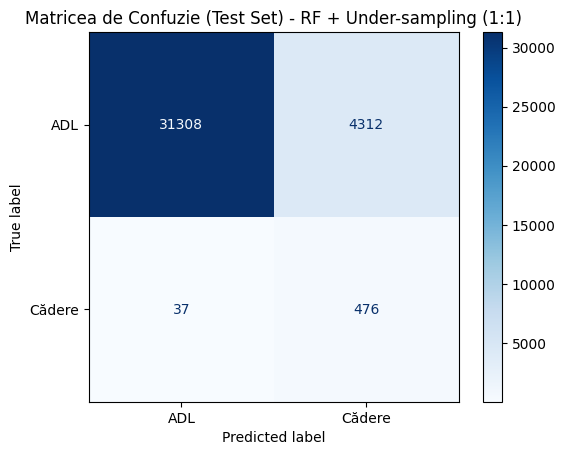


--- 9. Importanța Caracteristicilor ---


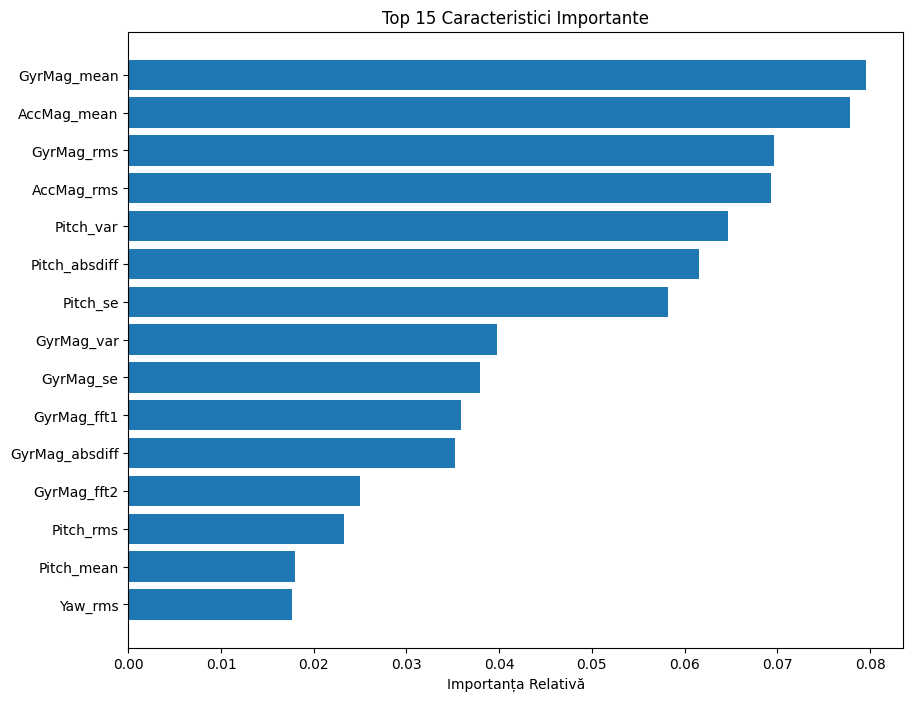

In [ ]:
import pandas as pd
import numpy as np
import os
import re
import matplotlib.pyplot as plt

from scipy.fft import rfft # Pentru Fast Fourier Transform
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer # CRUCIAL pentru a gestiona NaN-urile
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from imblearn.under_sampling import RandomUnderSampler

# --- 1. Parametrii de Segmentare (Din Articol) ---
SAMPLING_RATE_HZ = 100
WINDOW_SIZE_SEC = 0.5  # Fereastră de 0.5s
OVERLAP_PERCENT = 0.5

WINDOW_SIZE_SAMPLES = int(SAMPLING_RATE_HZ * WINDOW_SIZE_SEC) # 50 eșantioane
STEP_SIZE_SAMPLES = int(WINDOW_SIZE_SAMPLES * (1 - OVERLAP_PERCENT)) # 25 eșantioane

# Cele 9 axe brute pe care se bazează TOATE caracteristicile
SENSOR_COLUMNS = [
    'AccX', 'AccY', 'AccZ',
    'GyrX', 'GyrY', 'GyrZ',
    'EulerX', 'EulerY', 'EulerZ'
]
N_FEATURES_RAW = len(SENSOR_COLUMNS)

print(f"--- Configurare Extracție Caracteristici (Articol SVM) ---")
print(f"Mărime fereastră: {WINDOW_SIZE_SAMPLES} eșantioane")

# --- 2. Funcția de Extracție Avansată a Caracteristicilor (Total 40) ---

def get_signal_features(signal, include_fft=True):
    """
    Extrage caracteristicile statistice, temporale și de frecvență
    pentru un singur semnal (vector 1D).
    """
    features = []

    # 1. Basic: mean, var, rms
    mean = np.mean(signal)
    features.append(mean)
    features.append(np.var(signal))
    features.append(np.sqrt(np.mean(signal**2))) # RMS

    # 2. Temporal Avansat: ZCR, ABSDIFF
    # ZCR (Zero-Crossing Rate peste medie)
    zcr = np.sum(np.diff(np.sign(signal - mean)) != 0)
    features.append(zcr)

    # ABSDIFF (Absolute Difference)
    absdiff = np.mean(np.abs(signal - mean))
    features.append(absdiff)

    # 3. Frecvență (FFT)
    # Calculăm coeficienții FFT
    # Folosim rfft pentru semnale reale; n=window_size pentru consistență
    try:
        fft_coeffs = np.abs(rfft(signal, n=WINDOW_SIZE_SAMPLES))
        # Ignorăm componenta DC (index 0)
        fft_coeffs_no_dc = fft_coeffs[1:]
    except:
        # Eșec dacă semnalul este constant (ex: padding cu zerouri)
        fft_coeffs_no_dc = np.zeros(int(WINDOW_SIZE_SAMPLES / 2)) # Dimensiunea RFFT

    # Spectral Energy (SE)
    se = np.sum(fft_coeffs_no_dc**2) / (len(fft_coeffs_no_dc) + 1e-9)

    if include_fft:
        # 5 Coeficienți FFT (luăm primii 5 de după DC)
        top_5_fft = fft_coeffs_no_dc[:5]
        # Asigurăm 5 caracteristici chiar dacă FFT-ul e mai scurt
        if len(top_5_fft) < 5:
            top_5_fft = np.pad(top_5_fft, (0, 5 - len(top_5_fft)), 'constant')

        features.extend(top_5_fft) # 5 caracteristici
        features.append(se) # 1 caracteristică
        # Total: 5 (basic/temporal) + 5 (FFT) + 1 (SE) = 11
    else:
        features.append(se) # 1 caracteristică
        # Total: 5 (basic/temporal) + 1 (SE) = 6

    return features

def extract_features_40(window_data_raw):
    """
    Extrage cele 40 de caracteristici dintr-o fereastră de date brute (50, 9).
    """
    features = []

    # Calculăm Magnitudinile
    acc_mag = np.sqrt(window_data_raw[:, 0]**2 + window_data_raw[:, 1]**2 + window_data_raw[:, 2]**2)
    gyr_mag = np.sqrt(window_data_raw[:, 3]**2 + window_data_raw[:, 4]**2 + window_data_raw[:, 5]**2)

    # Extragem semnalele de orientare
    pitch = window_data_raw[:, 6] # EulerX
    roll = window_data_raw[:, 7]  # EulerY
    yaw = window_data_raw[:, 8]   # EulerZ

    # 1. Caracteristici AccMag (11)
    features.extend(get_signal_features(acc_mag, include_fft=True))

    # 2. Caracteristici GyrMag (11)
    features.extend(get_signal_features(gyr_mag, include_fft=True))

    # 3. Caracteristici Pitch (6)
    features.extend(get_signal_features(pitch, include_fft=False))

    # 4. Caracteristici Roll (6)
    features.extend(get_signal_features(roll, include_fft=False))

    # 5. Caracteristici Yaw (6)
    features.extend(get_signal_features(yaw, include_fft=False))

    # Total = 11 + 11 + 6 + 6 + 6 = 40 caracteristici
    return np.array(features)

# --- 3. Funcția de Segmentare și Extracție ---

def create_feature_windows(dataframe, event_interval, window_size, step_size):
    """
    Segmentează, aplică padding și extrage cele 40 de caracteristici.
    """
    feature_list = []
    labels = []

    for i in range(0, len(dataframe), step_size):
        end_index = i + window_size
        window_data = dataframe.iloc[i:end_index]

        # Extragem datele brute ale senzorilor (9 axe)
        window_sensors_raw = window_data[SENSOR_COLUMNS].values

        # --- Padding ---
        current_len = len(window_sensors_raw)
        if current_len < window_size:
            pad_len = window_size - current_len
            window_sensors_raw = np.pad(window_sensors_raw, ((0, pad_len), (0, 0)),
                                        'constant', constant_values=0)

        # --- Extracția Caracteristicilor (Noul pas) ---
        # Transformă (50, 9) într-un vector de (1, 40)
        extracted_features = extract_features_40(window_sensors_raw)

        # --- Etichetare (Pre-Impact) ---
        label = 0
        if event_interval is not None:
            onset_frame, impact_frame = event_interval
            min_frame = window_data['FrameCounter'].min()
            max_frame = window_data['FrameCounter'].max()
            if (min_frame <= impact_frame) and (max_frame >= onset_frame):
                label = 1

        feature_list.append(extracted_features)
        labels.append(label)

    return np.array(feature_list), np.array(labels)

# --- 4. Execuția Procesului (Colectare pe Subiect) ---

print("\n--- 4. Începe Procesarea (Extracție 40 Caracteristici) ---")
drive_base_path = '/content/drive/MyDrive/Licenta/Datasets/KFall Dataset'
label_data_path = os.path.join(drive_base_path, 'label_data')
sensor_data_path = os.path.join(drive_base_path, 'sensor_data')

all_data_by_subject = {}

try:
    label_files = [f for f in os.listdir(label_data_path) if f.endswith('_label.xlsx')]
    print(f"Am găsit {len(label_files)} subiecți...")

    for label_filename in label_files:
        subject_id = label_filename.split('_')[0]
        subject_id_sensor = subject_id.replace('SA', 'S')
        # print(f"Procesare Subiect: {subject_id}") # Dezactivat pentru viteză

        subject_sensor_dir = os.path.join(sensor_data_path, subject_id)
        if not os.path.isdir(subject_sensor_dir): continue

        subject_features = []
        subject_labels = []

        label_file_path = os.path.join(label_data_path, label_filename)
        df_labels = pd.read_excel(label_file_path)
        fall_files_set = set()

        # --- Sub-Bucla 1: CĂDERI ---
        for index, fall_info in df_labels.iterrows():
            try:
                onset_frame = fall_info['Fall_onset_frame']
                impact_frame = fall_info['Fall_impact_frame']
                raw_task_id_string = str(fall_info['Task Code (Task ID)'])
                match = re.search(r'\((\d+)\)', raw_task_id_string)
                if match is None: continue

                numeric_task_id = int(match.group(1))
                numeric_trial_id = fall_info['Trial ID']
                fall_filename = f"{subject_id_sensor}T{numeric_task_id:02d}R{numeric_trial_id:02d}.csv"
                fall_files_set.add(fall_filename)
                fall_file_path = os.path.join(subject_sensor_dir, fall_filename)

                df_fall = pd.read_csv(fall_file_path)

                features, labels = create_feature_windows(
                    df_fall,
                    (onset_frame, impact_frame),
                    WINDOW_SIZE_SAMPLES,
                    STEP_SIZE_SAMPLES
                )
                subject_features.append(features)
                subject_labels.append(labels)
            except Exception:
                pass

        # --- Sub-Bucla 2: ADL ---
        all_sensor_files = [f for f in os.listdir(subject_sensor_dir) if f.endswith('.csv')]
        for adl_filename in all_sensor_files:
            if adl_filename not in fall_files_set:
                try:
                    adl_file_path = os.path.join(subject_sensor_dir, adl_filename)
                    df_adl = pd.read_csv(adl_file_path)

                    features, labels = create_feature_windows(
                        df_adl,
                        None,
                        WINDOW_SIZE_SAMPLES,
                        STEP_SIZE_SAMPLES
                    )
                    subject_features.append(features)
                    subject_labels.append(labels)
                except Exception:
                    pass

        if subject_features:
            all_data_by_subject[subject_id] = {
                'X': np.concatenate(subject_features, axis=0),
                'y': np.concatenate(subject_labels, axis=0)
            }
            print(f"Procesat Subiect: {subject_id} - {len(all_data_by_subject[subject_id]['y'])} ferestre")

    # --- 5. Împărțire Train/Test BAZATĂ PE SUBIECT ---
    print("\n--- 5. Împărțirea Train/Test pe Subiect ---")

    all_subject_ids = list(all_data_by_subject.keys())
    train_subjects, test_subjects = train_test_split(all_subject_ids, test_size=0.2, random_state=42)

    X_train_list = [all_data_by_subject[s]['X'] for s in train_subjects]
    y_train_list = [all_data_by_subject[s]['y'] for s in train_subjects]
    X_test_list = [all_data_by_subject[s]['X'] for s in test_subjects]
    y_test_list = [all_data_by_subject[s]['y'] for s in test_subjects]

    X_train = np.concatenate(X_train_list, axis=0)
    y_train = np.concatenate(y_train_list, axis=0)
    X_test = np.concatenate(X_test_list, axis=0)
    y_test = np.concatenate(y_test_list, axis=0)

    print(f"\nForma X_train: {X_train.shape}")
    print(f"Forma X_test: {X_test.shape}")
    print(f"Distribuție y_train: {np.bincount(y_train)}")
    print(f"Distribuție y_test: {np.bincount(y_test)}")

    # --- 6. Curățarea și Scalarea Datelor ---
    print("\n--- 6. Curățarea (Imputare NaN) și Scalarea Datelor ---")

    # 1. Imputarea NaN-urilor (critice din cauza FFT-ului pe ferestre goale)
    imputer = SimpleImputer(strategy='constant', fill_value=0)
    X_train = imputer.fit_transform(X_train)
    X_test = imputer.transform(X_test)
    print("Valorile NaN au fost înlocuite.")

    # 2. Scalarea (StandardScaler)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    print("Datele au fost scalate.")

    print("\n--- 7. Antrenarea Modelului Random Forest ---")

    print(f"Distribuție y_train (înainte de RUS): {np.bincount(y_train)}")

    # --- PAS NOU: Aplicarea Random Under-sampling (Raport 1:1) ---
    rus = RandomUnderSampler(sampling_strategy=1.0, # 1.0 = raport 1:1
                         random_state=42)
    X_train_resampled, y_train_resampled = rus.fit_resample(X_train_scaled, y_train)

    print(f"Distribuție y_train (după RUS): {np.bincount(y_train_resampled)}")
    print(f"Dimensiune X_train (după RUS): {X_train_resampled.shape}")

    # --- PAS MODIFICAT: Antrenarea ---
    # Antrenăm pe datele 1:1 și eliminăm 'class_weight'
    model = RandomForestClassifier(
        n_estimators=150,
        # FĂRĂ class_weight (datele sunt deja echilibrate)
        random_state=42,
        n_jobs=-1
    )

    # Antrenăm pe noile date eșantionate
    model.fit(X_train_resampled, y_train_resampled)
    print("Model antrenat.")

    # --- 8. Evaluarea Modelului ---
    print("\n--- 8. REZULTATE ȘI METRICI (pe setul de TEST original) ---")
    # Evaluăm pe setul de test original, dezechilibrat
    y_pred = model.predict(X_test_scaled)

    print(f"Acuratețea Generală (Accuracy) pe Test: {accuracy_score(y_test, y_pred) * 100:.2f}%")
    print("\n--- Raport de Clasificare Detaliat ---")
    print(classification_report(y_test, y_pred, target_names=['ADL (Clasa 0)', 'Cădere (Clasa 1)']))

    print("\n--- Matrice de Confuzie ---")
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['ADL', 'Cădere'])
    disp.plot(cmap=plt.cm.Blues)
    plt.title("Matricea de Confuzie (Test Set) - RF + Under-sampling (1:1)")
    plt.show()

    # --- 9. Importanța Caracteristicilor (Opțional) ---
    try:
        print("\n--- 9. Importanța Caracteristicilor ---")
        feature_names = []
        signals = ['AccMag', 'GyrMag']
        stats_fft = ['mean', 'var', 'rms', 'zcr', 'absdiff', 'fft1', 'fft2', 'fft3', 'fft4', 'fft5', 'se']
        stats_no_fft = ['mean', 'var', 'rms', 'zcr', 'absdiff', 'se']

        for s in signals:
            for stat in stats_fft:
                feature_names.append(f"{s}_{stat}")
        for s in ['Pitch', 'Roll', 'Yaw']:
            for stat in stats_no_fft:
                feature_names.append(f"{s}_{stat}")

        importances = model.feature_importances_
        indices = np.argsort(importances)[-15:] # Top 15

        plt.figure(figsize=(10, 8))
        plt.title('Top 15 Caracteristici Importante')
        plt.barh(range(len(indices)), importances[indices], align='center')
        plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
        plt.xlabel('Importanța Relativă')
        plt.show()
    except Exception as e:
        print(f"Nu am putut afișa importanța caracteristicilor: {e}")

except Exception as e:
    print(f"A apărut o eroare majoră: {e}")
    import traceback
    traceback.print_exc()

# SisFall

In [ ]:
import os
import glob
import pandas as pd
import numpy as np
from scipy.signal import butter, lfilter
from scipy.integrate import trapezoid
from tqdm import tqdm
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, accuracy_score
from sklearn.preprocessing import StandardScaler


DATASET_PATH = '/content/drive/MyDrive/Licenta/Datasets/SisFall_dataset'

FS = 200.0

# Factori de conversie
ADXL_FACTOR = (2 * 16) / (2**13)  # ADXL345: +-16g, 13-bit
ITG_FACTOR = (2 * 2000) / (2**16)  # ITG3200: +-2000°/s, 16-bit
MMA_FACTOR = (2 * 8) / (2**14)  # MMA8451Q: +-8g, 14-bit


RAW_COLS = [
    'ADXL_x', 'ADXL_y', 'ADXL_z',
    'ITG_x', 'ITG_y', 'ITG_z',
    'MMA_x', 'MMA_y', 'MMA_z'
]

# Parametrii pentru Signal Processing
FILTER_ORDER = 4
FILTER_CUTOFF = 5
WINDOW_SEC = 2.0
WINDOW_SAMPLES = int(FS * WINDOW_SEC)
OVERLAP_RATIO = 0.5
STEP_SAMPLES = int(WINDOW_SAMPLES * (1 - OVERLAP_RATIO))


In [ ]:
# --- FUNCȚII HELPER PENTRU PRE-PROCESARE ---

def create_filter():
    """Creează și returnează coeficienții filtrului Butterworth."""
    nyquist = 0.5 * FS
    normal_cutoff = FILTER_CUTOFF / nyquist
    b, a = butter(FILTER_ORDER, normal_cutoff, btype='low', analog=False)
    return b, a

def apply_filter(data, b, a):
    """Aplică un filtru (b, a) pe datele de intrare."""
    return lfilter(b, a, data)

def convert_units(raw_df):
    """Convertește datele brute (biți) în unități fizice."""
    conv_df = raw_df.copy()
    conv_df.columns = RAW_COLS

    for col in RAW_COLS:
        conv_df[col] = pd.to_numeric(conv_df[col], errors='coerce')


    conv_df = conv_df.interpolate(method='linear', limit_direction='both')

    conv_df['ADXL_x'] *= ADXL_FACTOR
    conv_df['ADXL_y'] *= ADXL_FACTOR
    conv_df['ADXL_z'] *= ADXL_FACTOR

    conv_df['ITG_x'] *= ITG_FACTOR
    conv_df['ITG_y'] *= ITG_FACTOR
    conv_df['ITG_z'] *= ITG_FACTOR

    conv_df['MMA_x'] *= MMA_FACTOR
    conv_df['MMA_y'] *= MMA_FACTOR
    conv_df['MMA_z'] *= MMA_FACTOR

    return conv_df

# --- FUNCȚIA DE EXTRAGERE A CARACTERISTICILOR ---

def calculate_features(window_df):
    """
    Calculează caracteristicile C1-C14 pentru o singură fereastră de date.
    """


    ax = window_df['ADXL_x']
    ay = window_df['ADXL_y']
    az = window_df['ADXL_z']

    N = len(window_df)
    t = np.linspace(0, (N - 1) / FS, N)

    svm = np.sqrt(ax**2 + ay**2 + az**2)
    svm_hz = np.sqrt(ax**2 + az**2)

    features = {}

    try:
        features['C1'] = svm.mean()
        features['C2'] = svm_hz.mean()
        features['C3'] = svm.max() - svm.min()
        features['C4'] = np.mean(np.arctan2(svm_hz, -ay))
        features['C5'] = np.std(np.arctan2(svm_hz, ay))

        half_N = N // 2
        features['C6'] = ax.iloc[:half_N].mean() * ax.iloc[half_N:].mean()

        if t.size > 1:
            jerk_x = (ax.iloc[-1] - ax.iloc[0]) / (t[-1] - t[0])
            jerk_y = (ay.iloc[-1] - ay.iloc[0]) / (t[-1] - t[0])
            jerk_z = (az.iloc[-1] - az.iloc[0]) / (t[-1] - t[0])
            features['C7'] = np.sqrt(jerk_x**2 + jerk_y**2 + jerk_z**2)
        else:
            features['C7'] = 0

        features['C8'] = np.sqrt(ax.std()**2 + az.std()**2)
        features['C9'] = np.sqrt(ax.std()**2 + ay.std()**2 + az.std()**2)

        features['C10'] = (trapezoid(np.abs(ax), t) + trapezoid(np.abs(ay), t) + trapezoid(np.abs(az), t)) / N
        features['C11'] = (trapezoid(np.abs(ax), t) + trapezoid(np.abs(az), t)) / N
        features['C12'] = trapezoid(svm, t)
        features['C13'] = trapezoid(svm_hz, t)
        features['C14'] = (1/N) * np.sqrt(trapezoid(ax, t)**2 + trapezoid(az, t)**2)

    except Exception as e:
        print(f"Eroare la calcularea caracteristicilor: {e}")
        return None

    return features

In [ ]:
def process_all_files(dataset_path):
    """
    Funcția principală care iterează prin toate fișierele,
    le procesează și returnează un DataFrame final.
    --- VERSIUNE DE DEPANARE (cu sep=',') ---
    """

    all_files = []
    print(f"Se caută fișiere .txt în {dataset_path} folosind os.walk...")
    for root, dirs, files in os.walk(dataset_path):
        for file in files:
            if file.endswith(".txt"):
                all_files.append(os.path.join(root, file))

    if not all_files:
        print(f"EROARE: Nu s-au găsit fișiere .txt...")
        return None

    print(f"Am găsit {len(all_files)} fișiere. Începe procesarea...")

    all_features_list = []
    b, a = create_filter()

    count_skipped_name = 0
    count_skipped_cols = 0
    count_skipped_len = 0
    count_processed_ok = 0

    for file_path in tqdm(all_files, desc="Procesare fișiere"):
        filename = os.path.basename(file_path)

        try:
            if not (filename.startswith('F') or filename.startswith('D')):
                count_skipped_name += 1
                continue

            parts = filename.split('_')
            label = 1 if parts[0].startswith('F') else 0
            subject_id = parts[1]


            raw_df = pd.read_csv(
                file_path,
                sep=',',
                header=None,
                on_bad_lines='skip'
            )

            if raw_df.empty:
                count_skipped_name += 1
                continue

            # FILTRUL 1: Verificarea coloanelor
            if raw_df.shape[1] != 9:
                count_skipped_cols += 1
                continue

            # FILTRUL 2: Verificarea lungimii (WINDOW_SAMPLES = 400)
            if len(raw_df) < WINDOW_SAMPLES:
                count_skipped_len += 1
                continue

            # --- Dacă ajungem aici, e valid ---
            count_processed_ok += 1

            # Funcțiile 'convert_units' și 'calculate_features' sunt deja definite
            conv_df = convert_units(raw_df)
            filtered_df = conv_df.apply(lambda col: apply_filter(col, b, a), axis=0)

            for start in range(0, len(filtered_df) - WINDOW_SAMPLES + 1, STEP_SAMPLES):
                end = start + WINDOW_SAMPLES
                window = filtered_df.iloc[start:end].reset_index(drop=True)

                features = calculate_features(window)

                if features:
                    features['label'] = label
                    features['subject_id'] = subject_id
                    all_features_list.append(features)

        except Exception as e:
            print(f"Eroare la procesarea fișierului {filename}: {e}. Se continuă...")

    print("Procesare finalizată. Se creează DataFrame-ul final...")

    print("\n--- REZULTATE DEPANARE ---")
    print(f"Total fișiere găsite:                 {len(all_files)}")
    print(f"Sărite (nume invalid/gol):          {count_skipped_name}")
    print(f"Sărite (Nr. coloane != 9):        {count_skipped_cols}")
    print(f"Sărite (Prea scurte < {WINDOW_SAMPLES} rânduri): {count_skipped_len}")
    print(f"Fișiere valide procesate:           {count_processed_ok}")

    final_features_df = pd.DataFrame(all_features_list)
    final_features_df.dropna(inplace=True)

    return final_features_df

processed_data = process_all_files(DATASET_PATH)

if processed_data is not None and not processed_data.empty:
    print("\n--- REZUMAT DATE PROCESATE ---")
    print(f"Total ferestre (mostre de antrenare) create: {len(processed_data)}")
    print("\nDistribuția claselor (0=ADL, 1=FALL):")
    print(processed_data['label'].value_counts())
    print("\nPrimele 5 rânduri ale setului de date:")
    print(processed_data.head())
else:
    print("\n--- REZUMAT DATE PROCESATE ---")
    print("Nu s-au creat date de antrenare.")
    print("Verificați raportul de depanare de mai sus pentru a vedea de ce au fost sărite fișierele.")

Se caută fișiere .txt în /content/drive/MyDrive/Licenta/Datasets/SisFall_dataset folosind os.walk...
Am găsit 4506 fișiere. Începe procesarea...


Procesare fișiere: 100%|██████████| 4506/4506 [29:10<00:00,  2.57it/s]


Procesare finalizată. Se creează DataFrame-ul final...

--- REZULTATE DEPANARE ---
Total fișiere găsite:                 4506
Sărite (nume invalid/gol):          1
Sărite (Nr. coloane != 9):        0
Sărite (Prea scurte < 400 rânduri): 0
Fișiere valide procesate:           4505

--- REZUMAT DATE PROCESATE ---
Total ferestre (mostre de antrenare) create: 74409

Distribuția claselor (0=ADL, 1=FALL):
label
0    49359
1    25050
Name: count, dtype: int64

Primele 5 rânduri ale setului de date:
         C1        C2        C3        C4        C5        C6        C7  \
0  0.969815  0.306241  1.124199  0.320245  0.009432  0.000019  0.506236   
1  0.973086  0.355927  0.496027  0.391625  0.146859 -0.000023  0.089560   
2  1.021093  0.402196  1.495586  0.405604  0.190756  0.000006  0.068037   
3  1.054434  0.275021  1.495586  0.243678  0.169792 -0.000031  0.131889   
4  1.056460  0.267720  1.439283  0.309800  0.390605  0.000267  0.612366   

         C8        C9       C10       C11       C12   

In [ ]:
if processed_data is not None:
    FEATURES = [col for col in processed_data.columns if col not in ['label', 'subject_id']]
    X = processed_data[FEATURES]
    y = processed_data['label']
    groups = processed_data['subject_id'] # Grupurile pentru împărțire

    # Împărțire "Group-Aware" (bazată pe subiecți)
    # 30% din subiecți vor fi în setul de testare
    gss = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=42)
    train_idx, test_idx = next(gss.split(X, y, groups))

    X_train = X.iloc[train_idx]
    y_train = y.iloc[train_idx]

    X_test = X.iloc[test_idx]
    y_test = y.iloc[test_idx]

    train_subjects = processed_data.iloc[train_idx]['subject_id'].unique()
    test_subjects = processed_data.iloc[test_idx]['subject_id'].unique()

    print(f"Total subiecți: {len(groups.unique())}")
    print(f"Subiecți pentru antrenare ({len(train_subjects)}): {train_subjects}")
    print(f"Subiecți pentru testare ({len(test_subjects)}): {test_subjects}")
    print(f"\nDimensiune X_train: {X_train.shape}")
    print(f"Dimensiune X_test: {X_test.shape}")

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

Total subiecți: 38
Subiecți pentru antrenare (26): ['SE15' 'SE10' 'SE13' 'SE12' 'SE07' 'SE09' 'SE06' 'SE01' 'SE03' 'SA21'
 'SA23' 'SA22' 'SA20' 'SA19' 'SA17' 'SA15' 'SA12' 'SA13' 'SA10' 'SA11'
 'SA06' 'SA02' 'SA08' 'SA03' 'SA04' 'SA01']
Subiecți pentru testare (12): ['SE14' 'SE11' 'SE08' 'SE02' 'SE05' 'SE04' 'SA18' 'SA16' 'SA14' 'SA09'
 'SA05' 'SA07']

Dimensiune X_train: (53252, 14)
Dimensiune X_test: (21157, 14)



--- ÎNCEPERE ANTRANARE MODEL ---
Antrenare finalizată.

--- REZULTATE PE SETUL DE TESTARE ---
Acuratețea Generală: 83.50%

Raport de Clasificare:
              precision    recall  f1-score   support

     ADL (0)       0.88      0.89      0.88     14883
    Fall (1)       0.73      0.70      0.72      6274

    accuracy                           0.83     21157
   macro avg       0.80      0.80      0.80     21157
weighted avg       0.83      0.83      0.83     21157

Matricea de Confuzie:
(Axa Y = Adevărat, Axa X = Prezicere)


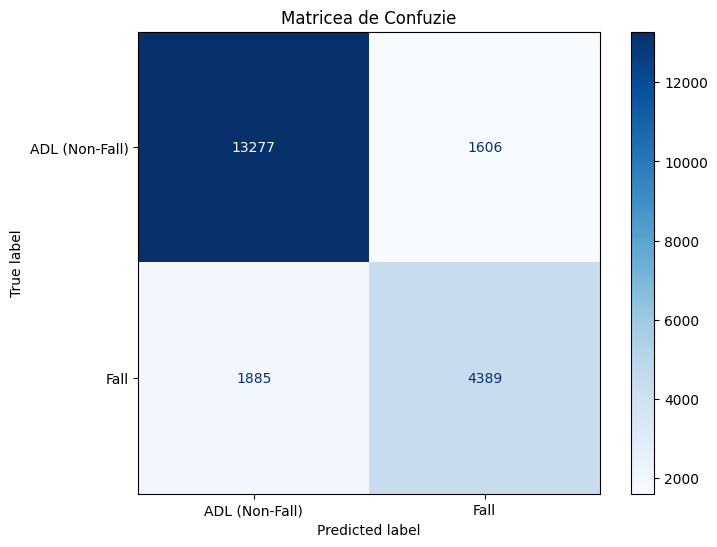

In [ ]:
if processed_data is not None:
    print("\n--- ÎNCEPERE ANTRANARE MODEL ---")


    model = RandomForestClassifier(
        n_estimators=150,
        random_state=42,
        class_weight='balanced',
        n_jobs=-1
    )

    # Antrenarea modelului
    model.fit(X_train_scaled, y_train)

    print("Antrenare finalizată.")

    # --- EVALUAREA MODELULUI ---
    print("\n--- REZULTATE PE SETUL DE TESTARE ---")

    # Realizarea predicțiilor pe setul de testare
    y_pred = model.predict(X_test_scaled)

    # Calcularea acurateței
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Acuratețea Generală: {accuracy * 100:.2f}%\n")

    # Afișarea Raportului de Clasificare
    print("Raport de Clasificare:")
    print(classification_report(y_test, y_pred, target_names=['ADL (0)', 'Fall (1)']))

    # Afișarea Matricei de Confuzie
    print("Matricea de Confuzie:")
    print("(Axa Y = Adevărat, Axa X = Prezicere)")

    fig, ax = plt.subplots(figsize=(8, 6))
    ConfusionMatrixDisplay.from_estimator(
        model,
        X_test_scaled,
        y_test,
        display_labels=['ADL (Non-Fall)', 'Fall'],
        cmap='Blues',
        ax=ax
    )
    plt.title("Matricea de Confuzie")
    plt.show()

--- REZULTATE CU PRAGUL IMPLICIT (0.5) ---
              precision    recall  f1-score   support

     ADL (0)       0.89      0.81      0.85     14883
    Fall (1)       0.63      0.76      0.69      6274

    accuracy                           0.80     21157
   macro avg       0.76      0.79      0.77     21157
weighted avg       0.81      0.80      0.80     21157

--- REZULTATE CU PRAGUL AJUSTAT (0.3) ---
Acuratețea Generală (Prag 0.3): 72.53%

Raport de Clasificare (Prag {NOUL_PRAG}):
              precision    recall  f1-score   support

     ADL (0)       0.91      0.67      0.78     14883
    Fall (1)       0.52      0.85      0.65      6274

    accuracy                           0.73     21157
   macro avg       0.72      0.76      0.71     21157
weighted avg       0.80      0.73      0.74     21157

Matricea de Confuzie (Prag {NOUL_PRAG}):


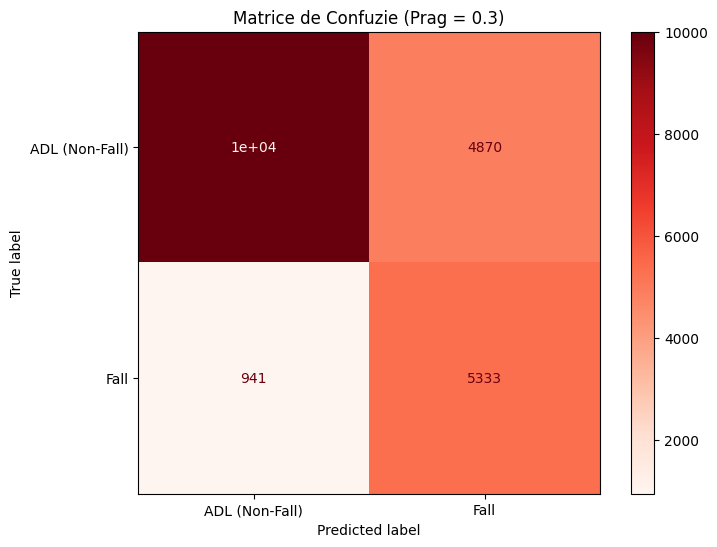

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, accuracy_score

# --- EVALUAREA MODELULUI CU UN PRAG NOU ---

print(f"--- REZULTATE CU PRAGUL IMPLICIT (0.5) ---")
y_pred_original = model_xgb.predict(X_test_scaled)
print(classification_report(y_test, y_pred_original, target_names=['ADL (0)', 'Fall (1)']))

# --- Pasul 1: Obținerea probabilităților ---
y_probs = model_xgb.predict_proba(X_test_scaled)

# Extragem doar probabilitățile pentru clasa "Fall" (clasa 1)
y_probs_fall = y_probs[:, 1]

# --- Pasul 2: Setarea noului prag ---
NOUL_PRAG = 0.30  # Încercăm 30% (poți experimenta cu 0.25, 0.35 etc.)

print("="*50)
print(f"--- REZULTATE CU PRAGUL AJUSTAT ({NOUL_PRAG}) ---")

# --- Pasul 3: Crearea noilor predicții ---
y_pred_new_threshold = (y_probs_fall > NOUL_PRAG).astype(int)

# --- Pasul 4: Afișarea noilor metrici ---
accuracy_new = accuracy_score(y_test, y_pred_new_threshold)
print(f"Acuratețea Generală (Prag {NOUL_PRAG}): {accuracy_new * 100:.2f}%\n")

print("Raport de Clasificare (Prag {NOUL_PRAG}):")
print(classification_report(y_test, y_pred_new_threshold, target_names=['ADL (0)', 'Fall (1)']))

# Afișarea Matricei de Confuzie pentru noul prag
print("Matricea de Confuzie (Prag {NOUL_PRAG}):")
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_new_threshold,
    display_labels=['ADL (Non-Fall)', 'Fall'],
    cmap='Reds',
    ax=ax
)
plt.title(f"Matrice de Confuzie (Prag = {NOUL_PRAG})")
plt.show()

XBoost

In [ ]:
!pip install xgboost
import xgboost as xgb
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt

print("\n--- ÎNCEPERE ANTRANARE MODEL XGBOOST ---")

# --- Calcularea ponderii pentru clasa dezechilibrată ---
count_adl = (y_train == 0).sum()
count_fall = (y_train == 1).sum()
scale_pos_weight_value = count_adl / count_fall

print(f"Setul de antrenare are {count_adl} mostre ADL și {count_fall} mostre Fall.")
print(f"Se setează 'scale_pos_weight' la: {scale_pos_weight_value:.2f}")

# Inițializarea modelului XGBoost
model_xgb = xgb.XGBClassifier(
    n_estimators=150,
    random_state=42,
    n_jobs=-1,
    scale_pos_weight=scale_pos_weight_value
)

# Antrenarea noului model
model_xgb.fit(X_train_scaled, y_train)

print("Antrenare XGBoost finalizată.")


--- ÎNCEPERE ANTRANARE MODEL XGBOOST ---
Setul de antrenare are 34476 mostre ADL și 18776 mostre Fall.
Se setează 'scale_pos_weight' la: 1.84
Antrenare XGBoost finalizată.



--- REZULTATE XGBOOST (Prag implicit 0.5) ---
Acuratețea Generală XGBoost: 79.78%

Raport de Clasificare (XGBoost):
              precision    recall  f1-score   support

     ADL (0)       0.89      0.81      0.85     14883
    Fall (1)       0.63      0.76      0.69      6274

    accuracy                           0.80     21157
   macro avg       0.76      0.79      0.77     21157
weighted avg       0.81      0.80      0.80     21157

Matricea de Confuzie (XGBoost):


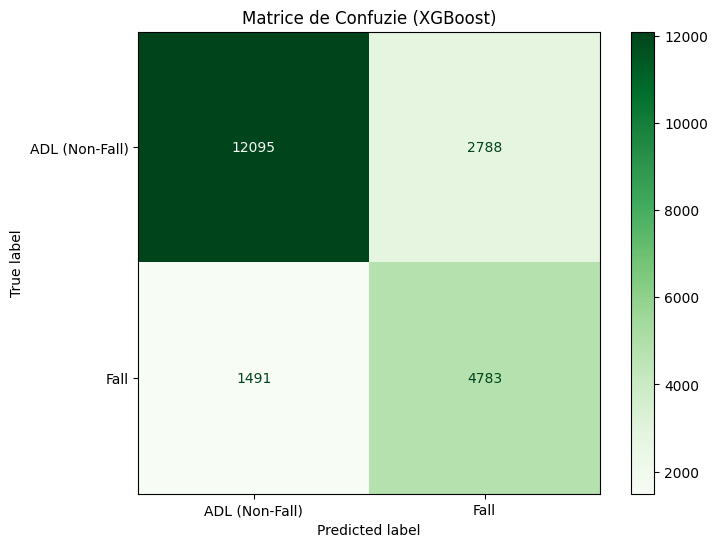

In [ ]:
print("\n--- REZULTATE XGBOOST (Prag implicit 0.5) ---")

# Realizarea predicțiilor pe setul de testare
y_pred_xgb = model_xgb.predict(X_test_scaled)

# Calcularea acurateței
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
print(f"Acuratețea Generală XGBoost: {accuracy_xgb * 100:.2f}%\n")

# Afișarea Raportului de Clasificare
print("Raport de Clasificare (XGBoost):")
print(classification_report(y_test, y_pred_xgb, target_names=['ADL (0)', 'Fall (1)']))

# Afișarea Matricei de Confuzie
print("Matricea de Confuzie (XGBoost):")
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(
    model_xgb,
    X_test_scaled,
    y_test,
    display_labels=['ADL (Non-Fall)', 'Fall'],
    cmap='Greens', # Schimbăm culoarea
    ax=ax
)
plt.title("Matrice de Confuzie (XGBoost)")
plt.show()

Hyperparameters

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
import xgboost as xgb
import numpy as np

print("\n--- ÎNCEPERE HYPERPARAMETER TUNING PENTRU XGBOOST ---")

# --- 1. Definirea "spațiului de căutare" ---
# Vom testa valori aleatorii din aceste liste
param_dist = {
    'n_estimators': [100, 150, 200, 300, 400],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7, 9],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0]
}

# --- 2. Re-crearea modelului de bază ---
if 'scale_pos_weight_value' not in locals():
     count_adl = (y_train == 0).sum()
     count_fall = (y_train == 1).sum()
     scale_pos_weight_value = count_adl / count_fall
     print("Valoarea scale_pos_weight a fost recalculată.")

model_base_xgb = xgb.XGBClassifier(
    random_state=42,
    n_jobs=-1,
    scale_pos_weight=scale_pos_weight_value
)

# --- 3. Configurarea Căutării Aleatorii ---
random_search = RandomizedSearchCV(
    estimator=model_base_xgb,
    param_distributions=param_dist,
    n_iter=20,
    cv=3,
    scoring='f1_weighted',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

print("Se potrivește modelul... Acest proces poate dura 5-10 minute.")
# --- 4. Rularea Căutării ---
random_search.fit(X_train_scaled, y_train)

print("Tuning finalizat.")
print("\nCea mai bună combinație de parametri găsită:")
print(random_search.best_params_)
print(f"\nCel mai bun scor F1-Weighted (din validare): {random_search.best_score_:.4f}")


--- ÎNCEPERE HYPERPARAMETER TUNING PENTRU XGBOOST ---
Se potrivește modelul... Acest proces poate dura 5-10 minute.
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Tuning finalizat.

Cea mai bună combinație de parametri găsită:
{'subsample': 0.9, 'n_estimators': 150, 'max_depth': 5, 'learning_rate': 0.01, 'colsample_bytree': 0.8}

Cel mai bun scor F1-Weighted (din validare): 0.8083



--- REZULTATE MODEL XGBOOST OPTIMIZAT (pe Setul de Testare) ---
Acuratețea Generală (Optimizat): 85.02%

Raport de Clasificare (Optimizat):
              precision    recall  f1-score   support

     ADL (0)       0.87      0.92      0.90     14883
    Fall (1)       0.78      0.68      0.73      6274

    accuracy                           0.85     21157
   macro avg       0.83      0.80      0.81     21157
weighted avg       0.85      0.85      0.85     21157

Matricea de Confuzie (Optimizat):


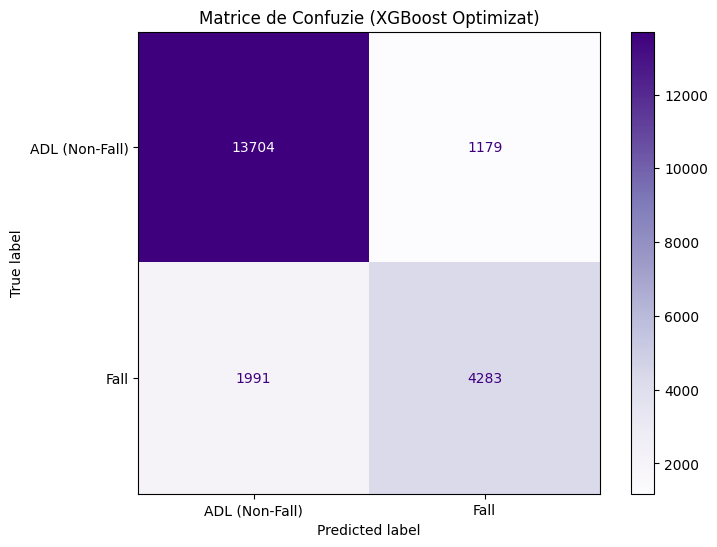

In [ ]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt

print("\n--- REZULTATE MODEL XGBOOST OPTIMIZAT (pe Setul de Testare) ---")

# Folosim cel mai bun model găsit ('random_search') pentru a face predicții
# Acesta folosește automat pragul implicit de 0.5
y_pred_tuned = random_search.predict(X_test_scaled)

# Calcularea acurateței
accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
print(f"Acuratețea Generală (Optimizat): {accuracy_tuned * 100:.2f}%\n")

# Afișarea Raportului de Clasificare
print("Raport de Clasificare (Optimizat):")
print(classification_report(y_test, y_pred_tuned, target_names=['ADL (0)', 'Fall (1)']))

# Afișarea Matricei de Confuzie
print("Matricea de Confuzie (Optimizat):")
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(
    random_search, # Folosim direct modelul 'random_search'
    X_test_scaled,
    y_test,
    display_labels=['ADL (Non-Fall)', 'Fall'],
    cmap='Purples', # O nouă culoare
    ax=ax
)
plt.title("Matrice de Confuzie (XGBoost Optimizat)")
plt.show()

--- REZULTATE CU PRAGUL IMPLICIT (0.5) ---
              precision    recall  f1-score   support

     ADL (0)       0.87      0.92      0.90     14883
    Fall (1)       0.78      0.68      0.73      6274

    accuracy                           0.85     21157
   macro avg       0.83      0.80      0.81     21157
weighted avg       0.85      0.85      0.85     21157

--- REZULTATE CU PRAGUL AJUSTAT (0.4) ---
Acuratețea Generală (Prag 0.4): 75.18%

Raport de Clasificare (Prag {NOUL_PRAG}):
              precision    recall  f1-score   support

     ADL (0)       0.91      0.72      0.80     14883
    Fall (1)       0.55      0.82      0.66      6274

    accuracy                           0.75     21157
   macro avg       0.73      0.77      0.73     21157
weighted avg       0.80      0.75      0.76     21157

Matricea de Confuzie (Prag {NOUL_PRAG}):


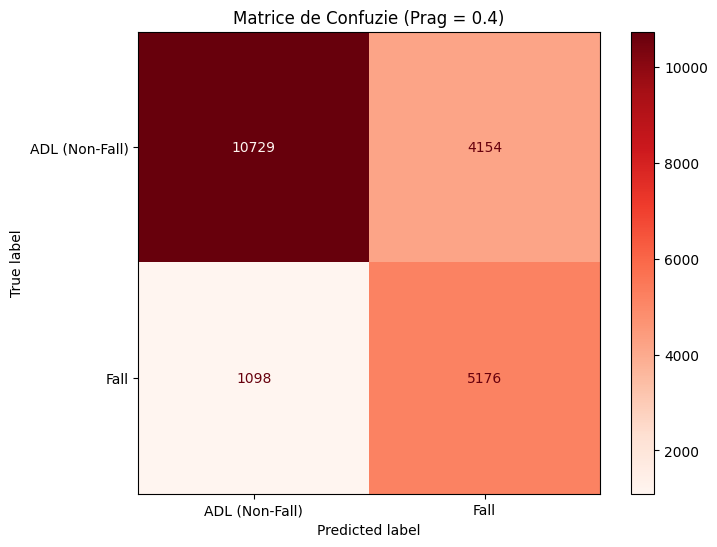

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, accuracy_score

# --- EVALUAREA MODELULUI CU UN PRAG NOU ---

print(f"--- REZULTATE CU PRAGUL IMPLICIT (0.5) ---")
y_pred_original = random_search.predict(X_test_scaled)
print(classification_report(y_test, y_pred_original, target_names=['ADL (0)', 'Fall (1)']))

# --- Pasul 1: Obținerea probabilităților ---
# model.predict_proba() ne dă un array [prob_clasa_0, prob_clasa_1]
y_probs = random_search.predict_proba(X_test_scaled)

y_probs_fall = y_probs[:, 1]

# --- Pasul 2: Setarea noului prag ---
NOUL_PRAG = 0.40

print("="*50)
print(f"--- REZULTATE CU PRAGUL AJUSTAT ({NOUL_PRAG}) ---")

# --- Pasul 3: Crearea noilor predicții ---
y_pred_new_threshold = (y_probs_fall > NOUL_PRAG).astype(int)

# --- Pasul 4: Afișarea noilor metrici ---
accuracy_new = accuracy_score(y_test, y_pred_new_threshold)
print(f"Acuratețea Generală (Prag {NOUL_PRAG}): {accuracy_new * 100:.2f}%\n")

print("Raport de Clasificare (Prag {NOUL_PRAG}):")
print(classification_report(y_test, y_pred_new_threshold, target_names=['ADL (0)', 'Fall (1)']))

# Afișarea Matricei de Confuzie pentru noul prag
print("Matricea de Confuzie (Prag {NOUL_PRAG}):")
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_new_threshold,
    display_labels=['ADL (Non-Fall)', 'Fall'],
    cmap='Reds',
    ax=ax
)
plt.title(f"Matrice de Confuzie (Prag = {NOUL_PRAG})")
plt.show()

## Deep Learning SisFall

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, accuracy_score
import numpy as np
import pandas as pd
import os
import glob
from tqdm import tqdm
import matplotlib.pyplot as plt

# Importăm din nou funcțiile de procesare a semnalului
from scipy.signal import butter, lfilter
from scipy.integrate import trapezoid

In [ ]:
import numpy as np
import pandas as pd
from scipy.signal import butter, lfilter
from scipy.integrate import trapezoid

# --- Constantele Globale ---
FS = 200.0
ADXL_FACTOR = (2 * 16) / (2**13)
ITG_FACTOR = (2 * 2000) / (2**16)
MMA_FACTOR = (2 * 8) / (2**14)
RAW_COLS = [
    'ADXL_x', 'ADXL_y', 'ADXL_z',
    'ITG_x', 'ITG_y', 'ITG_z',
    #'MMA_x', 'MMA_y', 'MMA_z'
]
FILTER_ORDER = 4
FILTER_CUTOFF = 5

# --- Funcțiile Helper ---

def create_filter():
    nyquist = 0.5 * FS
    normal_cutoff = FILTER_CUTOFF / nyquist
    b, a = butter(FILTER_ORDER, normal_cutoff, btype='low', analog=False)
    return b, a

def apply_filter(data, b, a):
    return lfilter(b, a, data)

def convert_units(raw_df):
    """
    Versiunea finală: convertește în numeric, interpolează,
    umple NaN-urile cu 0 ȘI înlocuiește valorile Infinite.
    """
    conv_df = raw_df.copy()
    conv_df.columns = RAW_COLS

    for col in RAW_COLS:
        conv_df[col] = pd.to_numeric(conv_df[col], errors='coerce')

    # Pasul 1: Încercăm să reparăm inteligent
    conv_df = conv_df.interpolate(method='linear', limit_direction='both')

    # Pasul 2: Reparare "brută" NaN. Umple forțat orice NaN rămas cu 0.
    conv_df = conv_df.fillna(0.0)

    # Pasul 3: Reparare "brută" Infinit.
    conv_df = conv_df.replace([np.inf, -np.inf], 0.0)

    # Aplicăm factorii
    conv_df['ADXL_x'] *= ADXL_FACTOR
    conv_df['ADXL_y'] *= ADXL_FACTOR
    conv_df['ADXL_z'] *= ADXL_FACTOR
    conv_df['ITG_x'] *= ITG_FACTOR
    conv_df['ITG_y'] *= ITG_FACTOR
    conv_df['ITG_z'] *= ITG_FACTOR
    #conv_df['MMA_x'] *= MMA_FACTOR
    #conv_df['MMA_y'] *= MMA_FACTOR
    #conv_df['MMA_z'] *= MMA_FACTOR

    return conv_df

In [ ]:

WINDOW_SEC = 2.0
WINDOW_SAMPLES = int(FS * WINDOW_SEC)
OVERLAP_RATIO = 0.5
STEP_SAMPLES = int(WINDOW_SAMPLES * (1 - OVERLAP_RATIO))

def create_dl_dataset(dataset_path):
    """
    Citește TOATE fișierele și creează un set de date
    sub formă de ferestre NumPy [N, 400, 9].
    """
    all_files = []
    for root, dirs, files in os.walk(dataset_path):
        for file in files:
            if file.endswith(".txt"):
                all_files.append(os.path.join(root, file))

    if not all_files:
        print(f"EROARE: Nu s-au găsit fișiere .txt în {dataset_path}")
        return None, None, None

    print(f"Am găsit {len(all_files)} fișiere. Se creează ferestrele DL...")

    # Listele unde vom stoca totul
    all_windows = []
    all_labels = []
    all_groups = []

    b, a = create_filter()

    for file_path in tqdm(all_files, desc="Procesare fișiere DL"):
        filename = os.path.basename(file_path)

        try:
            if not (filename.startswith('F') or filename.startswith('D')):
                continue

            parts = filename.split('_')
            label = 1 if parts[0].startswith('F') else 0
            subject_id = parts[1]

            raw_df = pd.read_csv(file_path, sep=',', header=None, on_bad_lines='skip')

            if raw_df.shape[1] != 9 or len(raw_df) < WINDOW_SAMPLES:
                continue

            raw_df = raw_df.iloc[:, :6]
            conv_df = convert_units(raw_df)
            filtered_df = conv_df.apply(lambda col: apply_filter(col, b, a), axis=0)

            # Procesul de segmentare (Windowing)
            for start in range(0, len(filtered_df) - WINDOW_SAMPLES + 1, STEP_SAMPLES):
                end = start + WINDOW_SAMPLES
                window = filtered_df.iloc[start:end]

                # ADĂUGĂM FEREASTRA BRUTĂ (ca NumPy array)
                all_windows.append(window.values)
                all_labels.append(label)
                all_groups.append(subject_id)

        except Exception as e:
            print(f"Eroare la procesarea {filename}: {e}. Se continuă...")

    print("Procesare finalizată. Se convertesc listele în array-uri NumPy...")

    # Convertim listele mari în array-uri NumPy eficiente
    X = np.stack(all_windows, axis=0)
    y = np.array(all_labels)
    groups = np.array(all_groups)

    return X, y, groups

# --- RULARE PROCESARE ---
DATASET_PATH = "/content/drive/MyDrive/Licenta/Datasets/SisFall_dataset"

X_dl, y_dl, groups_dl = create_dl_dataset(DATASET_PATH)

if X_dl is not None:
    print("\n--- REZUMAT DATE DEEP LEARNING ---")
    print(f"Forma datelor de intrare (X): {X_dl.shape}")
    print(f"Forma etichetelor (y): {y_dl.shape}")
    print(f"Total ferestre: {X_dl.shape[0]}")
    print(f"Lungime fereastră: {X_dl.shape[1]} (timestamps)")
    print(f"Număr axe (canale): {X_dl.shape[2]}")

Am găsit 4506 fișiere. Se creează ferestrele DL...


Procesare fișiere DL: 100%|██████████| 4506/4506 [00:56<00:00, 80.00it/s]


Procesare finalizată. Se convertesc listele în array-uri NumPy...

--- REZUMAT DATE DEEP LEARNING ---
Forma datelor de intrare (X): (74409, 400, 6)
Forma etichetelor (y): (74409,)
Total ferestre: 74409
Lungime fereastră: 400 (timestamps)
Număr axe (canale): 6


In [ ]:
from sklearn.preprocessing import MinMaxScaler # <-- IMPORT MODIFICAT

if 'X_dl' in locals():
    # --- 1. Împărțirea bazată pe subiecți (la fel ca înainte) ---
    gss = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=42)
    train_idx, test_idx = next(gss.split(X_dl, y_dl, groups_dl))

    X_train = X_dl[train_idx]
    y_train = y_dl[train_idx]

    X_test = X_dl[test_idx]
    y_test = y_dl[test_idx]

    print(f"Forma X_train: {X_train.shape}")
    print(f"Forma X_test: {X_test.shape}")

    # --- 2. Scalarea datelor (CU MINMAXSCALER) ---

    # --- MODIFICARE AICI ---
    # Scalăm datele între -1 și 1. Este mai robust.
    scaler = MinMaxScaler(feature_range=(-1, 1))
    # --- SFÂRȘIT MODIFICARE ---

    # Redimensionăm [N_train, 400, 9] -> [N_train * 400, 9]
    num_train_samples = X_train.shape[0]
    X_train_reshaped = X_train.reshape(-1, X_train.shape[-1])

    # Antrenăm scaler-ul DOAR pe datele de antrenare
    scaler.fit(X_train_reshaped)

    # Aplicăm transformarea
    X_train_scaled_reshaped = scaler.transform(X_train_reshaped)

    # Redimensionăm înapoi la [N_train, 400, 9]
    X_train_scaled = X_train_scaled_reshaped.reshape(num_train_samples, WINDOW_SAMPLES, X_train.shape[-1])

    # Acum aplicăm aceeași transformare pe datele de test
    num_test_samples = X_test.shape[0]
    X_test_reshaped = X_test.reshape(-1, X_test.shape[-1])
    X_test_scaled_reshaped = scaler.transform(X_test_reshaped)
    X_test_scaled = X_test_scaled_reshaped.reshape(num_test_samples, WINDOW_SAMPLES, X_test.shape[-1])

    print(f"Forma X_train_scaled: {X_train_scaled.shape}")
    print(f"Forma X_test_scaled: {X_test_scaled.shape}")
    print("--- COPIAZĂ ACESTE VALORI ÎN ARDUINO ---")
    print("float mins[6] = {", ", ".join(map(str, scaler.data_min_[:6])), "};")
    print("float maxs[6] = {", ", ".join(map(str, scaler.data_max_[:6])), "};")
else:
    print("Rulează mai întâi Pasul 3 (create_dl_dataset).")



Forma X_train: (53252, 400, 6)
Forma X_test: (21157, 400, 6)
Forma X_train_scaled: (53252, 400, 6)
Forma X_test_scaled: (21157, 400, 6)
--- COPIAZĂ ACESTE VALORI ÎN ARDUINO ---
float mins[6] = { -5.6964540534475665, -5.1464645289427535, -5.53894277845218, -1172.6378969897348, -819.9959347952149, -737.5901254413457 };
float maxs[6] = { 5.223630652262395, 3.3288508759237407, 5.449795844590118, 877.0843629802653, 701.9052085227835, 681.4031640016843 };


In [ ]:
def build_cnn_lstm_model(input_shape=(WINDOW_SAMPLES, 9)):
    """
    Construiește o arhitectură hibridă CNN-LSTM.
    CNN extrage trăsăturile, LSTM înțelege secvența temporală.
    """

    model = keras.Sequential()

    # --- BLOC 1: CNN (Extragere de trăsături) ---
    # Conv1D extrage tipare locale (vârfuri, pante)
    model.add(layers.Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=input_shape))
    model.add(layers.BatchNormalization()) # Ajută la stabilizare și viteză
    model.add(layers.MaxPooling1D(pool_size=2))

    # --- BLOC 2: CNN (Mai multe detalii) ---
    model.add(layers.Conv1D(filters=128, kernel_size=3, activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling1D(pool_size=2))

    # --- BLOC 3: LSTM (Înțelegerea secvenței) ---
    # Aici e diferența: Nu folosim Flatten() încă.
    # Păstrăm dimensiunea timpului și o dăm LSTM-ului.
    # return_sequences=False înseamnă că vrem un singur rezultat la finalul ferestrei
    model.add(layers.LSTM(64, return_sequences=False, dropout=0.3, recurrent_dropout=0.0))

    # --- BLOC 4: Clasificare ---
    model.add(layers.Dense(64, activation='relu'))
    model.add(layers.Dropout(0.5)) # Regularizare puternică
    model.add(layers.Dense(1, activation='sigmoid'))

    # --- OPTIMIZATOR ---
    # Păstrăm neapărat gradient clipping-ul!
    optimizer_adam = tf.keras.optimizers.Adam(
        learning_rate=0.001,
        clipnorm=1.0
    )

    model.compile(
        optimizer=optimizer_adam,
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

# Construirea modelului
if 'X_train_scaled' in locals():
    model = build_cnn_lstm_model(input_shape=(X_train_scaled.shape[1], X_train_scaled.shape[2]))
    print("Model Hibrid CNN-LSTM construit.")
    model.summary()
else:
    print("Rulează mai întâi celula de pregătire a datelor (Pasul 4).")

Model Hibrid CNN-LSTM construit.


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 398, 64)        │         1,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 398, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 199, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 197, 128)       │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 197, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 98, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 80,321 (313.75 KB)

 Trainable params: 79,937 (312.25 KB)

 Non-trainable params: 384 (1.50 KB)

In [ ]:
if 'model' in locals():
    # --- 1. Calcularea ponderilor pentru clase (Class Weights) ---
    weights = compute_class_weight(
        class_weight='balanced',
        classes=np.unique(y_train),
        y=y_train
    )
    class_weight_dict = {0: weights[0], 1: weights[1]}

    print(f"Ponderi Clase: ADL(0)={weights[0]:.2f}, Fall(1)={weights[1]:.2f}")

    # --- 2. Callback pentru Early Stopping ---
    # Oprește antrenarea dacă pierderea pe validare nu se îmbunătățește
    early_stopping = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    )

    # --- 3. Antrenarea ---
    print("Începe antrenarea modelului CNN...")
    history = model.fit(
        X_train_scaled,
        y_train,
        epochs=50,
        batch_size=32,
        validation_split=0.2,
        class_weight=class_weight_dict,
        callbacks=[early_stopping]
    )

    print("Antrenare finalizată.")
else:
    print("Rulează mai întâi celula de construire a modelului (Pasul 5).")

Ponderi Clase: ADL(0)=0.77, Fall(1)=1.42
Începe antrenarea modelului CNN...
Epoch 1/50
1332/1332 ━━━━━━━━━━━━━━━━━━━━ 172s 124ms/step - accuracy: 0.8032 - loss: 0.4610 - val_accuracy: 0.7742 - val_loss: 0.4742
Epoch 2/50
1332/1332 ━━━━━━━━━━━━━━━━━━━━ 202s 124ms/step - accuracy: 0.8307 - loss: 0.3948 - val_accuracy: 0.8079 - val_loss: 0.4132
Epoch 3/50
1332/1332 ━━━━━━━━━━━━━━━━━━━━ 160s 120ms/step - accuracy: 0.8596 - loss: 0.3416 - val_accuracy: 0.8040 - val_loss: 0.4781
Epoch 4/50
1332/1332 ━━━━━━━━━━━━━━━━━━━━ 203s 121ms/step - accuracy: 0.8785 - loss: 0.3034 - val_accuracy: 0.8279 - val_loss: 0.4094
Epoch 5/50
1332/1332 ━━━━━━━━━━━━━━━━━━━━ 164s 123ms/step - accuracy: 0.8884 - loss: 0.2862 - val_accuracy: 0.8248 - val_loss: 0.4363
Epoch 6/50
1332/1332 ━━━━━━━━━━━━━━━━━━━━ 161s 121ms/step - accuracy: 0.8948 - loss: 0.2696 - val_accuracy: 0.8374 - val_loss: 0.3995
Epoch 7/50
1332/1332 ━━━━━━━━━━━━━━━━━━━━ 163s 122ms/step - accuracy: 0.8986 - loss: 0.2555 - val_accuracy: 0.8248 - val

In [ ]:
if 'history' in locals():
    print("\n--- REZULTATE DEEP LEARNING (pe Setul de Testare) ---")

    # Obținem probabilitățile
    y_probs_cnn = model.predict(X_test_scaled).flatten() # .flatten() de la [N, 1] la [N,]

    # --- 1. Evaluare cu prag implicit (0.5) ---
    y_pred_cnn_05 = (y_probs_cnn > 0.5).astype(int)

    print("="*50)
    print("Raport de Clasificare (CNN @ Prag 0.5):")
    print(classification_report(y_test, y_pred_cnn_05, target_names=['ADL (0)', 'Fall (1)']))

    # --- 2. Evaluare cu prag ajustat (0.3) ---
    PRAG_SIGUR = 0.4
    y_pred_cnn_tuned = (y_probs_cnn > PRAG_SIGUR).astype(int)

    print("="*50)
    print(f"Raport de Clasificare (CNN @ Prag {PRAG_SIGUR}):")
    print(classification_report(y_test, y_pred_cnn_tuned, target_names=['ADL (0)', 'Fall (1)']))

    print("\n--- REZUMAT COMPARAȚIE ---")
    print(f"Baseline (XGBoost Sigur): Recall = 0.83, Precision = 0.55")
    print(f"Modelul CNN (Sigur): Verifică 'Fall (1)' -> 'recall' și 'precision' din raportul de mai sus.")

else:
    print("Rulează mai întâi celula de antrenare (Pasul 6).")


--- REZULTATE DEEP LEARNING (pe Setul de Testare) ---
662/662 ━━━━━━━━━━━━━━━━━━━━ 18s 27ms/step
Raport de Clasificare (CNN @ Prag 0.5):
              precision    recall  f1-score   support

     ADL (0)       0.93      0.83      0.88     14883
    Fall (1)       0.68      0.84      0.75      6274

    accuracy                           0.84     21157
   macro avg       0.80      0.84      0.81     21157
weighted avg       0.85      0.84      0.84     21157

Raport de Clasificare (CNN @ Prag 0.4):
              precision    recall  f1-score   support

     ADL (0)       0.94      0.77      0.85     14883
    Fall (1)       0.62      0.88      0.73      6274

    accuracy                           0.80     21157
   macro avg       0.78      0.83      0.79     21157
weighted avg       0.84      0.80      0.81     21157


--- REZUMAT COMPARAȚIE ---
Baseline (XGBoost Sigur): Recall = 0.83, Precision = 0.55
Modelul CNN (Sigur): Verifică 'Fall (1)' -> 'recall' și 'precision' din raportul d

In [ ]:
#Varianta de retea


def build_bidirectional_model(input_shape=(WINDOW_SAMPLES, 6)):
    model = keras.Sequential()

    # CNN Block 1
    model.add(layers.Conv1D(64, 3, activation='relu', input_shape=input_shape))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling1D(2))

    # CNN Block 2
    model.add(layers.Conv1D(128, 3, activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling1D(2))

    # --- SCHIMBARE AICI: Bidirectional LSTM ---
    # Citește secvența în ambele sensuri.
    # Atenție: Dublează numărul de neuroni (64x2 = 128 ieșiri)
    model.add(layers.Bidirectional(layers.LSTM(64, return_sequences=False, dropout=0.3)))

    # Clasificare
    model.add(layers.Dense(64, activation='relu'))
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(1, activation='sigmoid'))

    optimizer_adam = tf.keras.optimizers.Adam(learning_rate=0.001, clipnorm=1.0)
    model.compile(optimizer=optimizer_adam, loss='binary_crossentropy', metrics=['accuracy'])

    return model

# Construirea modelului
if 'X_train_scaled' in locals():
    model = build_bidirectional_model(input_shape=(X_train_scaled.shape[1], X_train_scaled.shape[2]))
    print("Model Hibrid CNN-LSTM construit.")
    model.summary()
else:
    print("Rulează mai întâi celula de pregătire a datelor (Pasul 4).")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model Hibrid CNN-LSTM construit.


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 398, 64)        │         1,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 398, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 199, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 197, 128)       │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 197, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 98, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 133,825 (522.75 KB)

 Trainable params: 133,441 (521.25 KB)

 Non-trainable params: 384 (1.50 KB)

In [ ]:
#Varianta2 retea

# def build_gap_model(input_shape=(WINDOW_SAMPLES, 6)):
#     model = keras.Sequential()

#     # CNN Block 1
#     model.add(layers.Conv1D(64, 5, activation='relu', input_shape=input_shape)) # Kernel mai mare (5)
#     model.add(layers.BatchNormalization())
#     model.add(layers.MaxPooling1D(2))

#     # CNN Block 2
#     model.add(layers.Conv1D(128, 3, activation='relu'))
#     model.add(layers.BatchNormalization())
#     # Nu mai facem MaxPooling aici, lăsăm secvența mai lungă

#     # LSTM
#     # return_sequences=True pentru că GAP vine DUPĂ LSTM
#     #model.add(layers.LSTM(64, return_sequences=True, dropout=0.3, unroll=True))

#     # --- SCHIMBARE MAJORĂ: Global Average Pooling ---
#     # În loc de Flatten -> Dense, facem media
#     #model.add(layers.GlobalAveragePooling1D())

#     # --- ELIMINĂM LSTM, MAI ADĂUGĂM UN CNN ---
#     model.add(layers.Conv1D(64, 3, activation='relu'))
#     model.add(layers.GlobalAveragePooling1D())

#     # Clasificare directă (sau cu un mic Dense înainte)
#     model.add(layers.Dropout(0.5))
#     model.add(layers.Dense(1, activation='sigmoid'))

#     optimizer_adam = tf.keras.optimizers.Adam(learning_rate=0.001, clipnorm=1.0)
#     model.compile(optimizer=optimizer_adam, loss='binary_crossentropy', metrics=['accuracy'])

#     return model


# # Construirea modelului
# if 'X_train_scaled' in locals():
#     model = build_gap_model(input_shape=(X_train_scaled.shape[1], X_train_scaled.shape[2]))
#     print("Model Hibrid CNN-LSTM construit.")
#     model.summary()
# else:
#     print("Rulează mai întâi celula de pregătire a datelor (Pasul 4).")

def build_gap_model(input_shape=(WINDOW_SAMPLES, 6)):
    model = keras.Sequential()

    # --- BLOCK 1 ---
    model.add(layers.Conv1D(16, 5, activation='relu', input_shape=input_shape))
    model.add(layers.MaxPooling1D(2))

    # --- BLOCK 2 ---
    model.add(layers.Conv1D(32, 3, activation='relu'))
    model.add(layers.MaxPooling1D(2))

    # --- FLATTEN ---
    model.add(layers.Flatten())

    # --- CLASIFICARE ---
    model.add(layers.Dense(1, activation='sigmoid'))

    optimizer_adam = tf.keras.optimizers.Adam(learning_rate=0.001)
    model.compile(optimizer=optimizer_adam, loss='binary_crossentropy', metrics=['accuracy'])

    return model

# Construire și sumar
if 'X_train_scaled' in locals():
    model = build_gap_model(input_shape=(X_train_scaled.shape[1], X_train_scaled.shape[2]))
    print("Model CNN-Flatten (Safe for ESP32) construit.")
    model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model CNN-Flatten (Safe for ESP32) construit.


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 396, 16)        │           496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 198, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 196, 32)        │         1,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 98, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         3,137 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,201 (20.32 KB)

 Trainable params: 5,201 (20.32 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#Varianta3 model


def build_multi_head_model(input_shape=(WINDOW_SAMPLES, 6)):
    # Functional API
    inputs = layers.Input(shape=input_shape)

    # --- RAMURA 1: Detalii fine (Kernel mic) ---
    head1 = layers.Conv1D(32, kernel_size=3, activation='relu', padding='same')(inputs)
    head1 = layers.BatchNormalization()(head1)
    head1 = layers.MaxPooling1D(2)(head1)

    # --- RAMURA 2: Mișcări medii (Kernel mediu) ---
    head2 = layers.Conv1D(32, kernel_size=5, activation='relu', padding='same')(inputs)
    head2 = layers.BatchNormalization()(head2)
    head2 = layers.MaxPooling1D(2)(head2)

    # --- RAMURA 3: Mișcări ample (Kernel mare) ---
    head3 = layers.Conv1D(32, kernel_size=11, activation='relu', padding='same')(inputs)
    head3 = layers.BatchNormalization()(head3)
    head3 = layers.MaxPooling1D(2)(head3)

    # Concatenăm rezultatele
    merged = layers.Concatenate()([head1, head2, head3])

    # Continuăm cu LSTM
    x = layers.Conv1D(64, 3, activation='relu')(merged) # Reducem dimensiunea
    x = layers.MaxPooling1D(2)(x)

    # LSTM
    x = layers.LSTM(64, return_sequences=False, dropout=0.3)(x)

    # Clasificare
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = keras.Model(inputs=inputs, outputs=outputs)

    optimizer_adam = tf.keras.optimizers.Adam(learning_rate=0.001, clipnorm=1.0)
    model.compile(optimizer=optimizer_adam, loss='binary_crossentropy', metrics=['accuracy'])

    return model


# Construirea modelului
if 'X_train_scaled' in locals():
    model = build_multi_head_model(input_shape=(X_train_scaled.shape[1], X_train_scaled.shape[2]))
    print("Model Hibrid CNN-LSTM construit.")
    model.summary()
else:
    print("Rulează mai întâi celula de pregătire a datelor (Pasul 4).")

Model Hibrid CNN-LSTM construit.


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 400, 6)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 400, 32)   │        608 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 400, 32)   │        992 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 400, 32)   │      2,144 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 400, 32)   │        128 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 400, 32)   │        128 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 400, 32)   │        128 │ conv1d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 200, 32)   │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_1     │ (None, 200, 32)   │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_2     │ (None, 200, 32)   │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 200, 96)   │          0 │ max_pooling1d[0]… │
│ (Concatenate)       │                   │            │ max_pooling1d_1[… │
│                     │                   │            │ max_pooling1d_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 198, 64)   │     18,496 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_3     │ (None, 99, 64)    │          0 │ conv1d_3[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 64)        │     33,024 │ max_pooling1d_3[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      4,160 │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │         65 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 59,873 (233.88 KB)

 Trainable params: 59,681 (233.13 KB)

 Non-trainable params: 192 (768.00 B)

# Transformare model pentru trecerea pe esp32


In [ ]:
import tensorflow as tf
import numpy as np



import tensorflow as tf

# Convertor
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS]
converter.target_spec.supported_types = [tf.float32]

# Conversie
tflite_model = converter.convert()

# Salvare
with open('model.tflite', 'wb') as f:
    f.write(tflite_model)

print(f"Model ATOMIC salvat! Dimensiune: {len(tflite_model)/1024:.2f} KB")

Saved artifact at '/tmp/tmp12uzqcq3'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 400, 6), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  133572391239120: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133572123394896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133572123395664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133572123394512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133572123399120: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133572123399888: TensorSpec(shape=(), dtype=tf.resource, name=None)
Model ATOMIC salvat! Dimensiune: 24.96 KB


In [ ]:

!xxd -i model.tflite > model_data.h

!head -n 5 model_data.h

from google.colab import files
files.download('model_data.h')

unsigned char model_tflite[] = {
  0x1c, 0x00, 0x00, 0x00, 0x54, 0x46, 0x4c, 0x33, 0x14, 0x00, 0x20, 0x00,
  0x1c, 0x00, 0x18, 0x00, 0x14, 0x00, 0x10, 0x00, 0x0c, 0x00, 0x00, 0x00,
  0x08, 0x00, 0x04, 0x00, 0x14, 0x00, 0x00, 0x00, 0x1c, 0x00, 0x00, 0x00,
  0x8c, 0x00, 0x00, 0x00, 0xe4, 0x00, 0x00, 0x00, 0x34, 0x54, 0x00, 0x00,


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import numpy as np

# 1. Căutăm indecșii pentru un caz POZITIV (Cădere) și unul NEGATIV (Mers normal)
idx_fall = np.where(y_test == 1)[0][0]
idx_normal = np.where(y_test == 0)[0][0]

# 2. Extragem datele și le aplatizăm (flatten) pentru că ESP32 vrea un singur șir lung
sample_fall = X_test[idx_fall].flatten()
sample_normal = X_test[idx_normal].flatten()

# 3. Funcție pentru a genera string-ul C++
def generate_c_array(name, data):
    # Convertim la string cu 4 zecimale
    data_str = ", ".join([f"{x:.4f}" for x in data])
    print(f"// Exemplu: {name}")
    print(f"float {name}[] = {{{data_str}}};")
    print(f"// Lungime: {len(data)}\n")

print("-" * 30)
print("-" * 30)

generate_c_array("input_fall", sample_fall)
generate_c_array("input_normal", sample_normal)

------------------------------
COPIAZĂ LINIIDE DE MAI JOS ÎN ARDUINO:
------------------------------
// Exemplu: input_fall
float input_fall[] = {-0.0000, -0.0000, 0.0000, 0.0000, 0.0001, 0.0000, -0.0000, -0.0003, 0.0000, 0.0001, 0.0012, 0.0000, -0.0001, -0.0011, 0.0002, 0.0002, 0.0052, 0.0002, -0.0002, -0.0033, 0.0006, 0.0007, 0.0155, 0.0005, -0.0006, -0.0077, 0.0014, 0.0015, 0.0358, 0.0012, -0.0011, -0.0151, 0.0027, 0.0028, 0.0705, 0.0023, -0.0019, -0.0264, 0.0047, 0.0047, 0.1231, 0.0041, -0.0030, -0.0422, 0.0074, 0.0071, 0.1969, 0.0064, -0.0044, -0.0630, 0.0111, 0.0101, 0.2941, 0.0092, -0.0062, -0.0891, 0.0158, 0.0135, 0.4159, 0.0123, -0.0084, -0.1206, 0.0213, 0.0172, 0.5626, 0.0154, -0.0109, -0.1575, 0.0279, 0.0209, 0.7334, 0.0181, -0.0138, -0.1993, 0.0353, 0.0239, 0.9266, 0.0200, -0.0170, -0.2457, 0.0436, 0.0258, 1.1397, 0.0208, -0.0204, -0.2961, 0.0526, 0.0259, 1.3697, 0.0201, -0.0241, -0.3497, 0.0622, 0.0232, 1.6130, 0.0176, -0.0279, -0.4058, 0.0722, 0.0172, 1.8657, 0.0133, -0.0